In [ ]:
# Data Science
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import re
import seaborn as sns
from tqdm.notebook import tqdm
import pgeocode
from collections import Counter
import requests
import pandas as pd
import wbgapi as wb
import pycountry
import time as time_module

# Preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

# Handling class imbalance
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline  # replaces sklearn Pipeline when using SMOTE
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# Models and evaluation
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold, StratifiedKFold

# Linear Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import LearningCurveDisplay

# Tree-based Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb

# Metrics
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    classification_report,
    f1_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    make_scorer,
    fbeta_score,
    matthews_corrcoef,
    precision_recall_curve
)
from MLstatkit import Delong_test
from mlxtend.evaluate import cochrans_q, mcnemar, mcnemar_table
from statsmodels.stats.contingency_tables import mcnemar as sm_mcnemar
import shap

# Saving Optimal Model 
import joblib, os


# Create Dataset

In [29]:
clinical = pd.read_csv("../hantavirus_data/hantavirus_clinical.csv")
clinical

,patient_id,year,country,syndrome,age,sex,symptoms,incubation_days,severity,hospitalized,...,dialysis,comorbidity,exposure_type,outcome,length_of_stay_days,blood_type,viral_load_category,days_to_diagnosis,treatment_protocol,geographic_setting
0,PT-00001,2026,MV Hondius (International),HPS,82,Male,"Hypotension, Chills, Abdominal Pain, Vomiting,...",22,Severe,1,...,0,NaN,Cruise ship exposure,Deceased,6,O+,High,2,Vasopressors + mechanical ventilation,Remote
1,PT-00002,2026,MV Hondius (International),HPS,73,Female,"Pulmonary Edema, Hypotension, Dyspnea, Cough",13,Severe,1,...,0,Hypertension,Cruise ship exposure,Deceased,28,A+,Low,3,ECMO + full ICU support,Remote
2,PT-00003,2026,MV Hondius (International),HPS,62,Female,"Vomiting, Chills, Hypotension, Myalgia, Tachyc...",9,Critical,1,...,0,Immunosuppression,Cruise ship exposure,Deceased,19,O+,Low,4,ECMO + full ICU support,Remote
3,PT-00004,2026,MV Hondius (International),HPS,82,Female,"Diarrhea, Myalgia, Nausea, Chills, Dizziness, ...",21,Critical,1,...,0,Asthma,Cruise ship exposure,Recovered,22,O-,Critical,5,Vasopressors + mechanical ventilation,Remote
4,PT-00005,2026,MV Hondius (International),HPS,74,Male,"Chills, Fever, Pulmonary Edema, Myalgia",12,Severe,1,...,0,Cardiovascular Disease,Cruise ship exposure,Recovered,14,A+,High,5,Supportive care only,Remote
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,PT-09996,2025,USA,HPS,37,Female,"Dizziness, Headache, Pulmonary Edema",29,Severe,1,...,0,NaN,Rural dwelling,Recovered,17,A+,Low,7,Dialysis + supportive,Rural
9996,PT-09997,2019,Canada,HPS,58,Female,"Hypotension, Vomiting, Myalgia, Diarrhea, Fati...",20,Severe,1,...,0,NaN,Camping/hiking,Deceased,10,AB+,High,1,Vasopressors + mechanical ventilation,Urban
9997,PT-09998,2015,Colombia,HPS,21,Female,"Tachycardia, Cough, Dizziness",24,Severe,1,...,0,Hypertension,Cleaning rodent-infested area,Recovered,16,O+,Critical,1,IV fluids + oxygen,Peri-urban
9998,PT-09999,2004,South Korea,HFRS,24,Female,"Petechiae, Headache, Blurred Vision",28,Moderate,1,...,0,Smoking,Agricultural work,Recovered,15,A+,Low,8,IV fluids + oxygen,Remote


In [30]:
country_yearly = pd.read_csv("../hantavirus_data/hantavirus_country_yearly.csv")
country_yearly 

,year,iso3,country,who_region,latitude,longitude,syndrome,confirmed_cases,deaths,recovered,case_fatality_rate,hospitalized,icu_admissions,human_to_human_cases
0,1993,ARG,Argentina,AMRO,-34.60,-58.40,HPS,35,11,24,0.3426,30,8,0
1,1993,CHL,Chile,AMRO,-33.40,-70.60,HPS,0,0,0,0.2587,0,0,0
2,1993,BRA,Brazil,AMRO,-15.80,-47.90,HPS,0,0,0,0.4455,0,0,0
3,1993,BOL,Bolivia,AMRO,-16.50,-68.20,HPS,0,0,0,0.2775,0,0,0
4,1993,PRY,Paraguay,AMRO,-25.30,-57.60,HPS,0,0,0,0.2666,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
845,2026,FRA,France,EURO,48.90,2.30,HFRS,101,0,101,0.0012,82,26,0
846,2026,HRV,Croatia,EURO,45.80,16.00,HFRS,82,2,80,0.0349,76,14,0
847,2026,SVN,Slovenia,EURO,46.10,14.50,HFRS,46,1,45,0.0307,40,12,0
848,2026,GRC,Greece,EURO,37.97,23.73,HFRS,12,0,12,0.0262,10,2,0


In [31]:
# Merge clinical and country_yearly on country and year

# Add prefix to country_yearly columns before merging
country_yearly_prefixed = country_yearly.add_prefix('cy_')

# Rename the merge keys back so the join works
country_yearly_prefixed = country_yearly_prefixed.rename(columns={
    'cy_country': 'country',
    'cy_year': 'year'
})

# Merge
data = pd.merge(clinical, country_yearly_prefixed, on=["country", "year"], how="left")
data

,patient_id,year,country,syndrome,age,sex,symptoms,incubation_days,severity,hospitalized,...,cy_latitude,cy_longitude,cy_syndrome,cy_confirmed_cases,cy_deaths,cy_recovered,cy_case_fatality_rate,cy_hospitalized,cy_icu_admissions,cy_human_to_human_cases
0,PT-00001,2026,MV Hondius (International),HPS,82,Male,"Hypotension, Chills, Abdominal Pain, Vomiting,...",22,Severe,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PT-00002,2026,MV Hondius (International),HPS,73,Female,"Pulmonary Edema, Hypotension, Dyspnea, Cough",13,Severe,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PT-00003,2026,MV Hondius (International),HPS,62,Female,"Vomiting, Chills, Hypotension, Myalgia, Tachyc...",9,Critical,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PT-00004,2026,MV Hondius (International),HPS,82,Female,"Diarrhea, Myalgia, Nausea, Chills, Dizziness, ...",21,Critical,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PT-00005,2026,MV Hondius (International),HPS,74,Male,"Chills, Fever, Pulmonary Edema, Myalgia",12,Severe,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,PT-09996,2025,USA,HPS,37,Female,"Dizziness, Headache, Pulmonary Edema",29,Severe,1,...,38.9,-77.0,HPS,58.0,17.0,41.0,0.3067,50.0,8.0,0.0
9996,PT-09997,2019,Canada,HPS,58,Female,"Hypotension, Vomiting, Myalgia, Diarrhea, Fati...",20,Severe,1,...,45.4,-75.7,HPS,3.0,0.0,3.0,0.3038,2.0,0.0,0.0
9997,PT-09998,2015,Colombia,HPS,21,Female,"Tachycardia, Cough, Dizziness",24,Severe,1,...,4.7,-74.1,HPS,7.0,2.0,5.0,0.2997,5.0,0.0,0.0
9998,PT-09999,2004,South Korea,HFRS,24,Female,"Petechiae, Headache, Blurred Vision",28,Moderate,1,...,37.6,127.0,HFRS,528.0,8.0,520.0,0.0152,453.0,129.0,0.0


In [32]:
def get_coords(iso3):
    r = requests.get(f"https://restcountries.com/v3.1/alpha/{iso3}").json()
    lat, lon = r[0]['latlng']
    return lat, lon

def get_country_summary(iso3):

    # --- Open-Meteo Archive ---
    lat, lon = get_coords(iso3)
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": "2010-01-01",
        "end_date": "2023-12-31",  # avoid 2024 which may be incomplete
        "daily": ["temperature_2m_mean", "precipitation_sum"],
        "timezone": "UTC"
    }
    response = requests.get(url, params=params)
    data = response.json()

    df_climate = pd.DataFrame(data['daily'])
    df_climate['date'] = pd.to_datetime(df_climate['time'])
    df_climate = df_climate.drop(columns=['time']).set_index('date').resample('YE').mean()
    climate_results = {
        'avg_temperature': df_climate['temperature_2m_mean'].mean(),
        'avg_precipitation': df_climate['precipitation_sum'].mean()
    }

    # --- WDI ---
    indicators = {
        'SP.RUR.TOTL.ZS':    'rural_pop_pct',
        'SP.URB.TOTL.IN.ZS': 'urban_pop_pct',
        'EN.POP.DNST':       'pop_density',
        'NY.GNP.PCAP.PP.CD': 'gni_per_capita',
        'SP.DYN.LE00.IN':    'life_expectancy',
    }
    df_wdi = wb.data.DataFrame(
        list(indicators.keys()),
        economy=iso3,
        time=range(2010, 2024)
    ).T.rename(columns=indicators)
    wdi_results = df_wdi.mean().to_dict()

    summary = {'country': iso3, **climate_results, **wdi_results}
    return pd.DataFrame([summary])

In [33]:
def get_iso3(country_name):
    try:
        return pycountry.countries.search_fuzzy(country_name)[0].alpha_3
    except LookupError:
        return None  # or "UNK" if you need a non-null sentinel

# Build the mapping once (avoid re-searching for repeated values)
unique_countries = data['country'].unique()
iso3_map = {c: get_iso3(c) for c in unique_countries}

# Collect summaries only for countries that resolved successfully
summaries = []
for country, iso3 in tqdm(iso3_map.items(), desc="Processing countries"):
    if iso3 is None:
        continue
    try:
        summaries.append(get_country_summary(iso3))
        time_module.sleep(10)  # be polite to the API
    except Exception as e:
        print(f"Skipping {country} ({iso3}): {e}")

country_features = pd.concat(summaries, ignore_index=True)

# Report anything that failed
failed = [c for c, code in iso3_map.items() if code is None]
if failed:
    print("Could not resolve:", failed)

data['country_code'] = data['country'].map(iso3_map)

# Merge back via the iso3 code already on data
data = data.merge(country_features, left_on='country_code', right_on='country', how='left') \
           .drop(columns='country_y') \
           .rename(columns={'country_x': 'country'})

Processing countries:   0%|          | 0/19 [00:00<?, ?it/s]

Could not resolve: ['MV Hondius (International)']


In [34]:
lat, lon = get_coords('ARG')
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": "2010-01-01",
    "end_date": "2024-12-31",
    "daily": ["temperature_2m_mean", "precipitation_sum"],
    "timezone": "UTC"
}
r = requests.get(url, params=params).json()
print(r)

{'latitude': -33.989456, 'longitude': -64.04492, 'generationtime_ms': 135.07258892059326, 'utc_offset_seconds': 0, 'timezone': 'GMT', 'timezone_abbreviation': 'GMT', 'elevation': 148.0, 'daily_units': {'time': 'iso8601', 'temperature_2m_mean': '°C', 'precipitation_sum': 'mm'}, 'daily': {'time': ['2010-01-01', '2010-01-02', '2010-01-03', '2010-01-04', '2010-01-05', '2010-01-06', '2010-01-07', '2010-01-08', '2010-01-09', '2010-01-10', '2010-01-11', '2010-01-12', '2010-01-13', '2010-01-14', '2010-01-15', '2010-01-16', '2010-01-17', '2010-01-18', '2010-01-19', '2010-01-20', '2010-01-21', '2010-01-22', '2010-01-23', '2010-01-24', '2010-01-25', '2010-01-26', '2010-01-27', '2010-01-28', '2010-01-29', '2010-01-30', '2010-01-31', '2010-02-01', '2010-02-02', '2010-02-03', '2010-02-04', '2010-02-05', '2010-02-06', '2010-02-07', '2010-02-08', '2010-02-09', '2010-02-10', '2010-02-11', '2010-02-12', '2010-02-13', '2010-02-14', '2010-02-15', '2010-02-16', '2010-02-17', '2010-02-18', '2010-02-19', '20

In [35]:
data

,patient_id,year,country,syndrome,age,sex,symptoms,incubation_days,severity,hospitalized,...,cy_icu_admissions,cy_human_to_human_cases,country_code,avg_temperature,avg_precipitation,pop_density,gni_per_capita,life_expectancy,rural_pop_pct,urban_pop_pct
0,PT-00001,2026,MV Hondius (International),HPS,82,Male,"Hypotension, Chills, Abdominal Pain, Vomiting,...",22,Severe,1,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PT-00002,2026,MV Hondius (International),HPS,73,Female,"Pulmonary Edema, Hypotension, Dyspnea, Cough",13,Severe,1,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PT-00003,2026,MV Hondius (International),HPS,62,Female,"Vomiting, Chills, Hypotension, Myalgia, Tachyc...",9,Critical,1,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PT-00004,2026,MV Hondius (International),HPS,82,Female,"Diarrhea, Myalgia, Nausea, Chills, Dizziness, ...",21,Critical,1,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PT-00005,2026,MV Hondius (International),HPS,74,Male,"Chills, Fever, Pulmonary Edema, Myalgia",12,Severe,1,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,PT-09996,2025,USA,HPS,37,Female,"Dizziness, Headache, Pulmonary Edema",29,Severe,1,...,8.0,0.0,USA,14.278577,2.239200,35.432118,61941.428571,78.273693,19.617525,80.382475
9996,PT-09997,2019,Canada,HPS,58,Female,"Hypotension, Vomiting, Myalgia, Diarrhea, Fati...",20,Severe,1,...,0.0,0.0,CAN,-6.929536,1.189878,4.097197,48416.428571,81.659739,18.435541,81.564459
9997,PT-09998,2015,Colombia,HPS,21,Female,"Tachycardia, Cough, Dizziness",24,Severe,1,...,0.0,0.0,COL,26.098927,5.775950,43.508530,14565.714286,75.801714,22.659428,77.340572
9998,PT-09999,2004,South Korea,HFRS,24,Female,"Petechiae, Headache, Blurred Vision",28,Moderate,1,...,129.0,0.0,KOR,11.985690,3.207493,523.839028,43470.714286,82.167247,18.471364,81.528636


# EDA

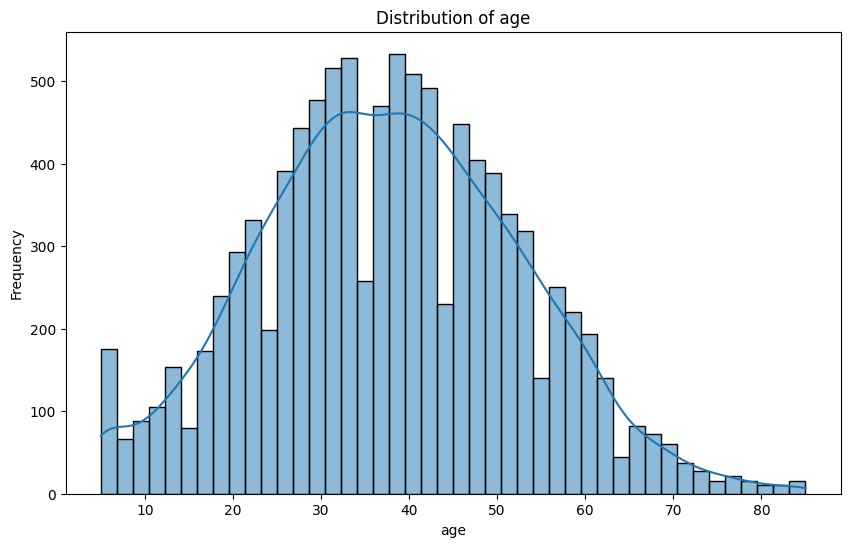

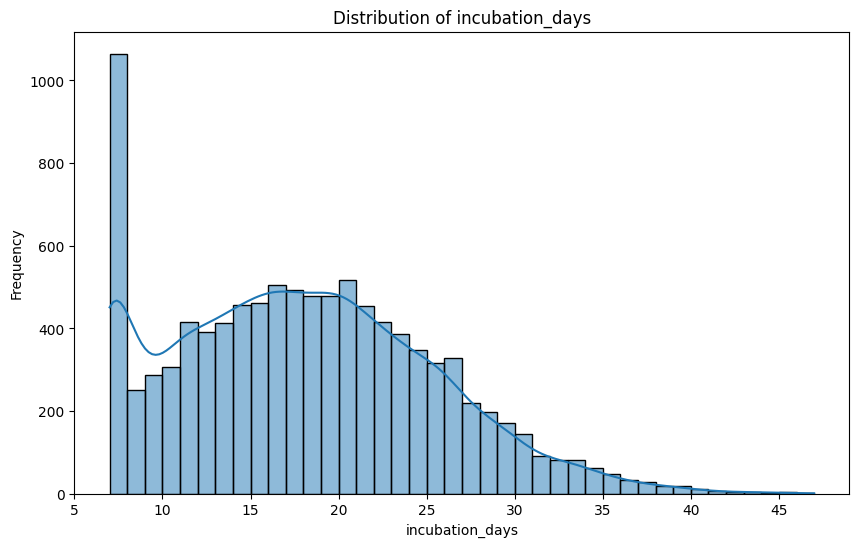

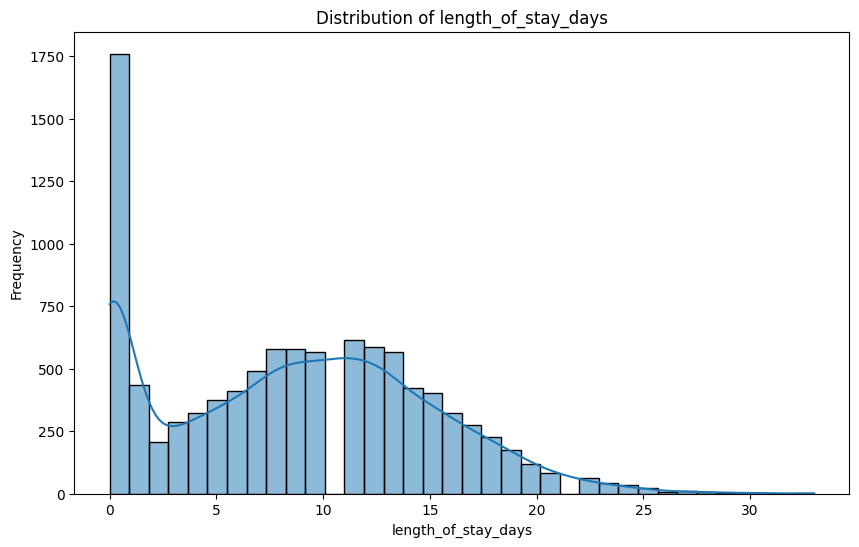

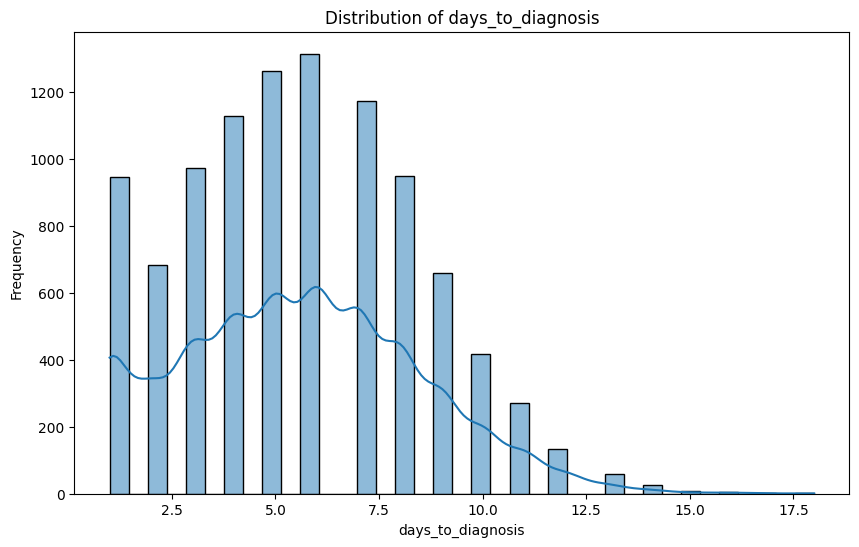

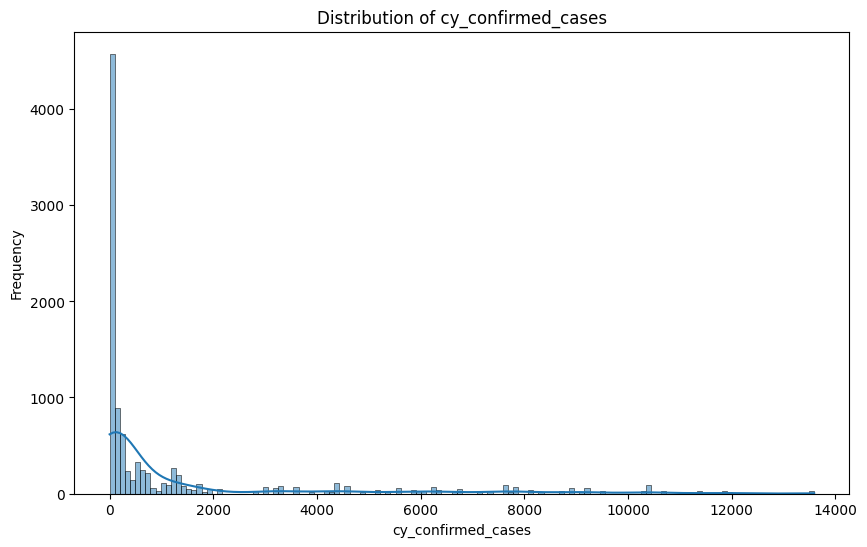

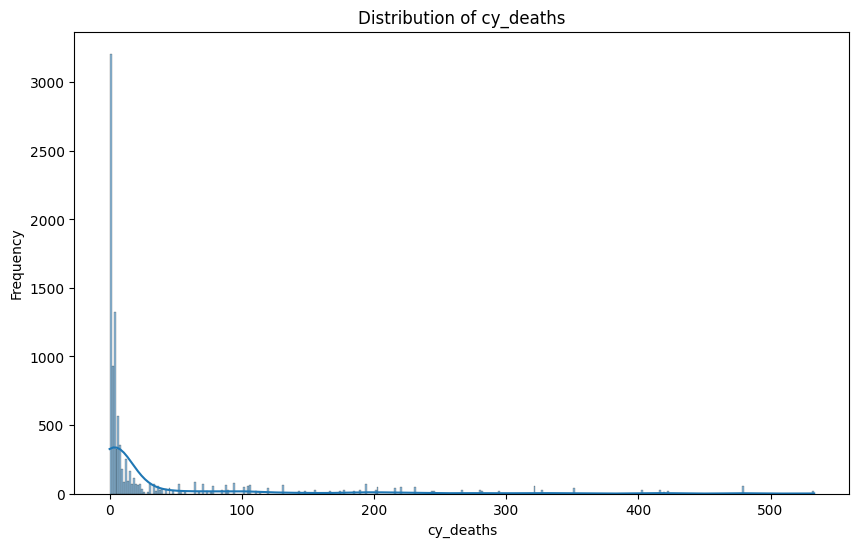

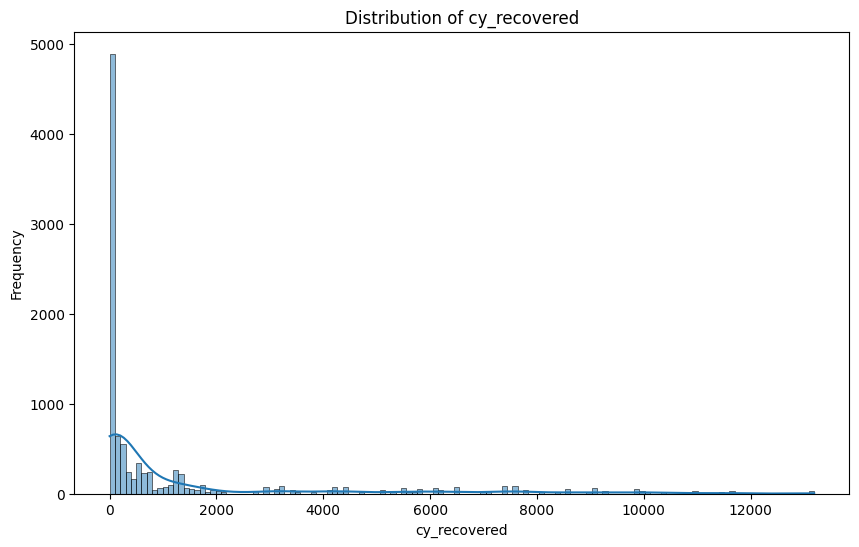

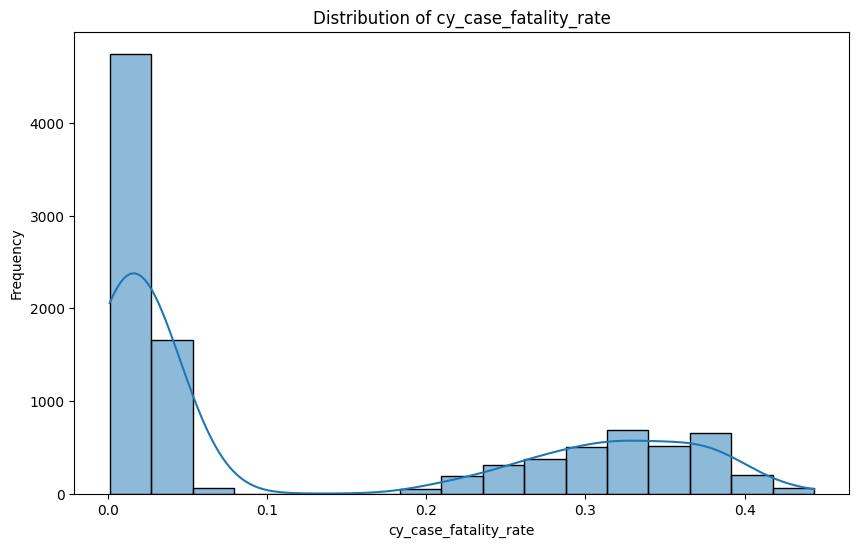

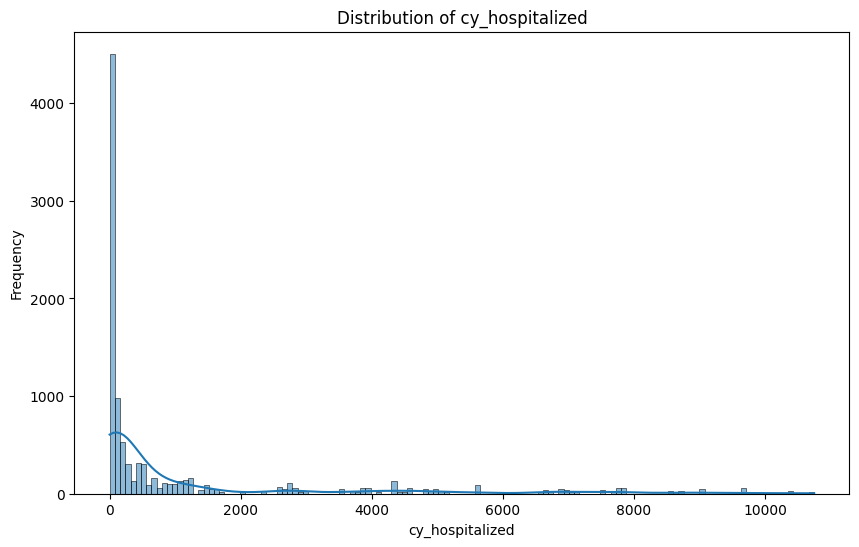

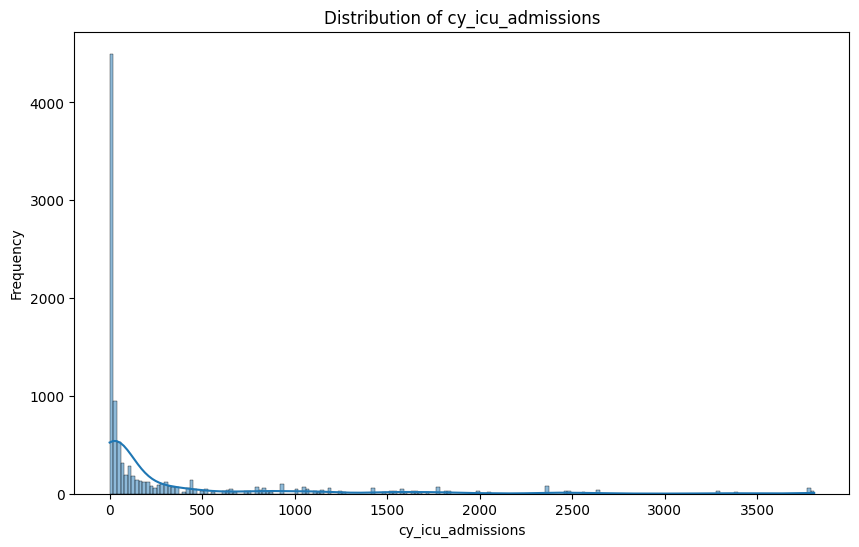

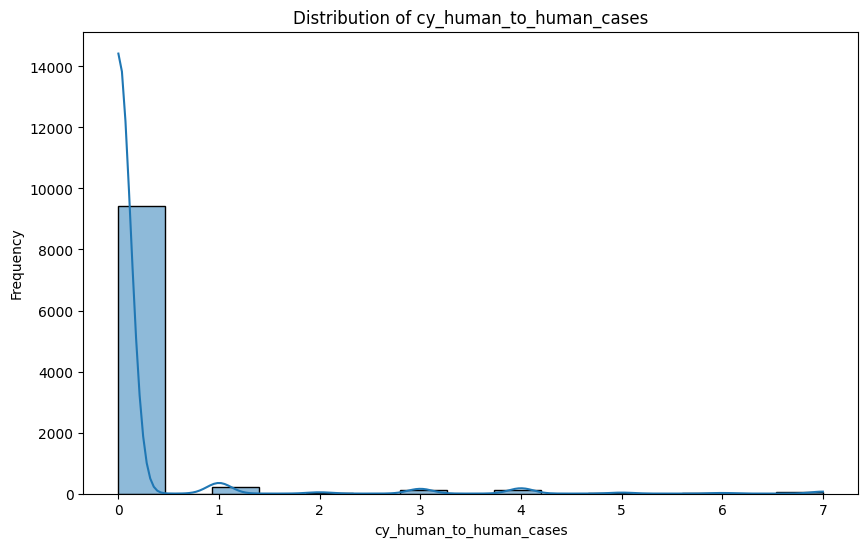

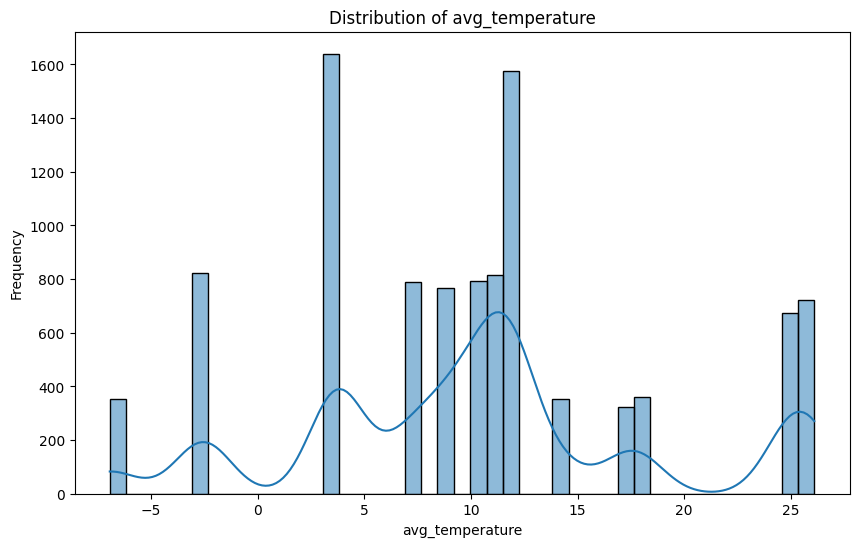

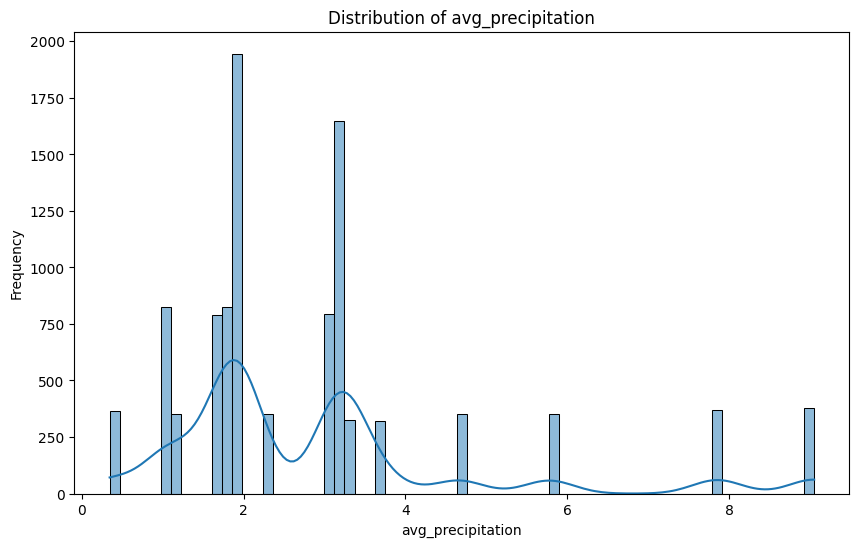

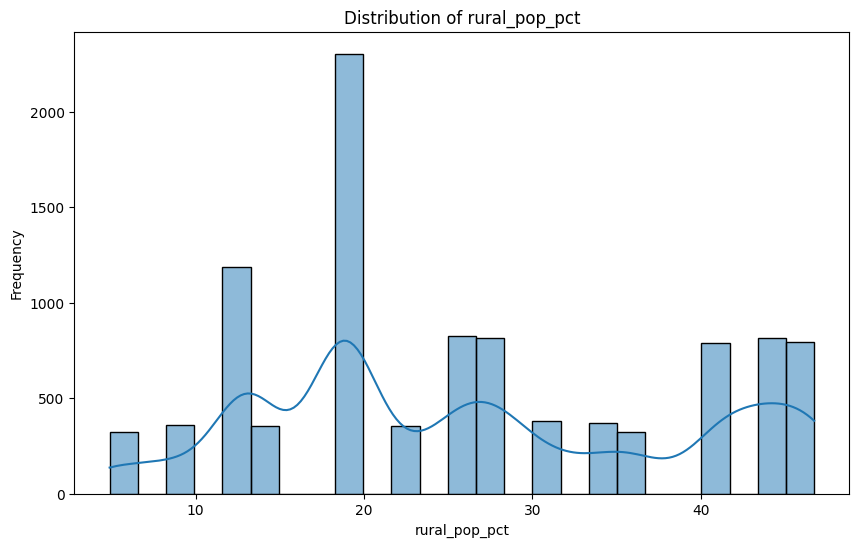

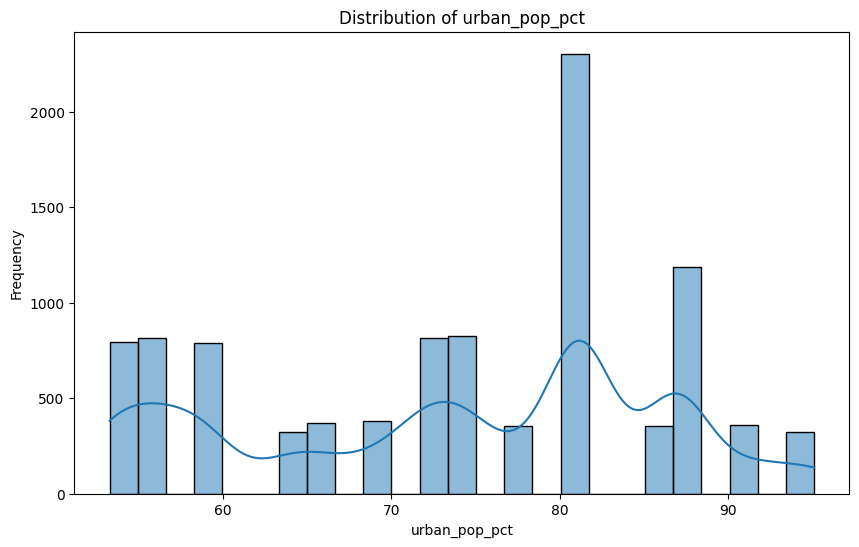

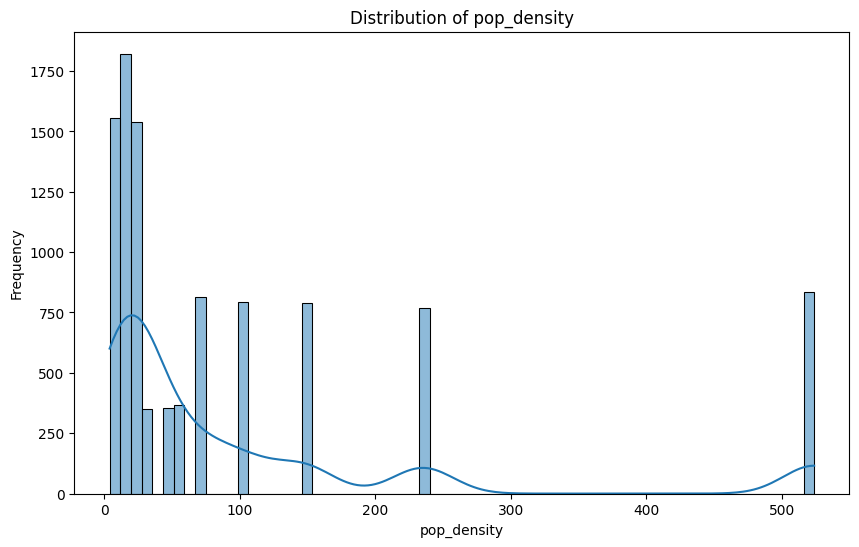

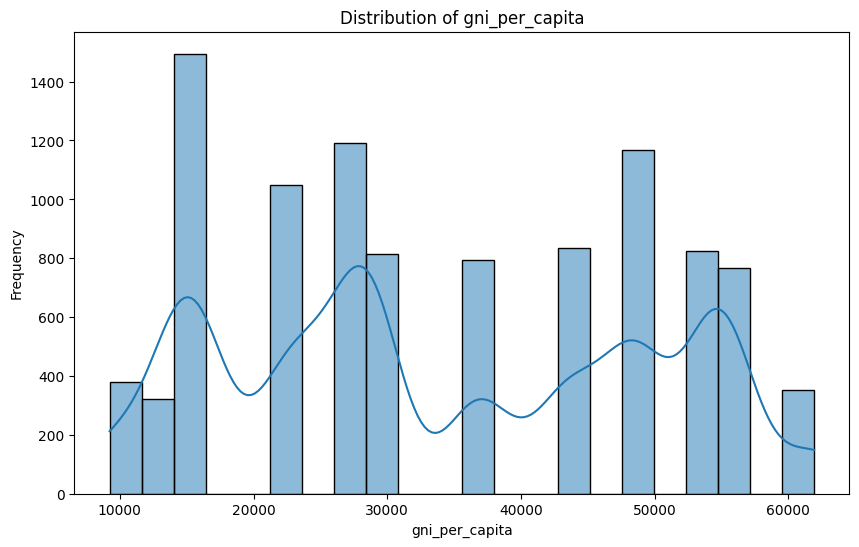

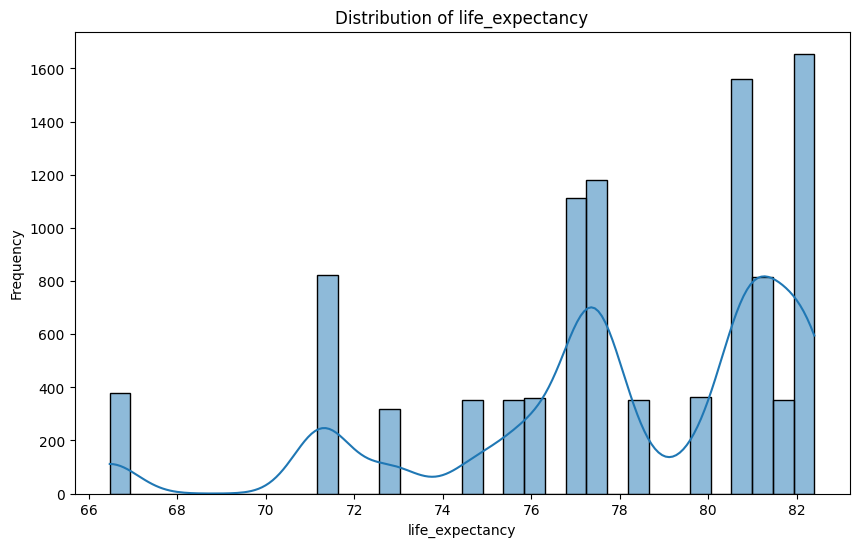

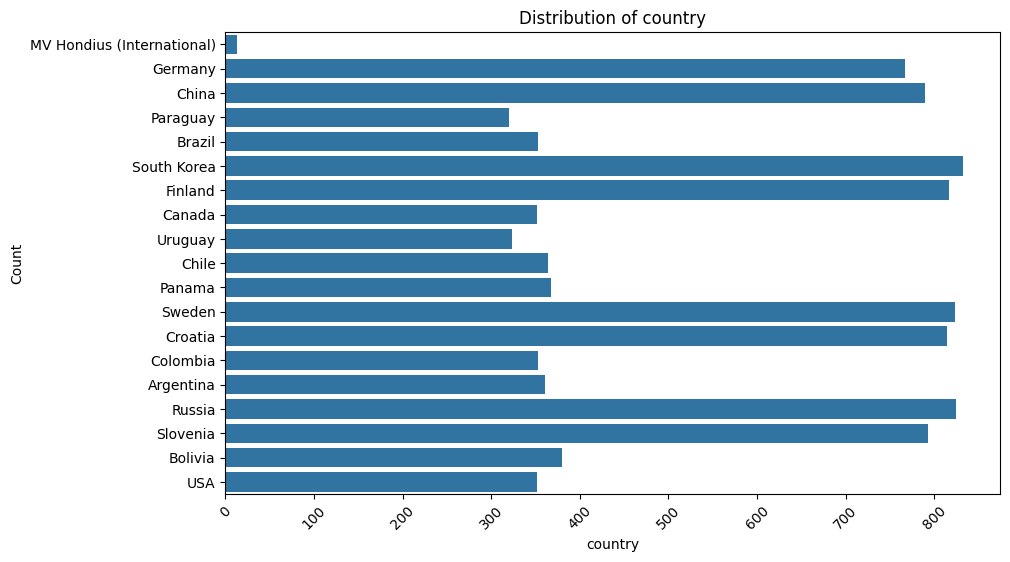

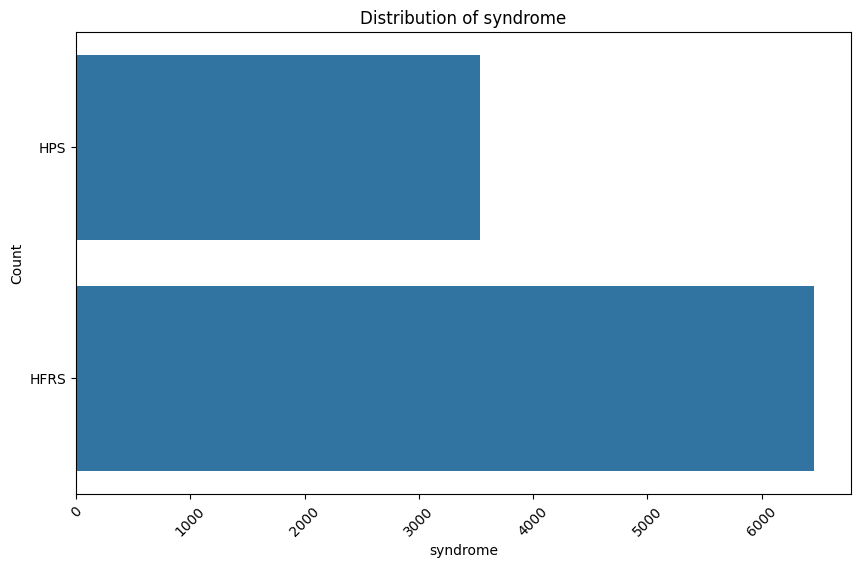

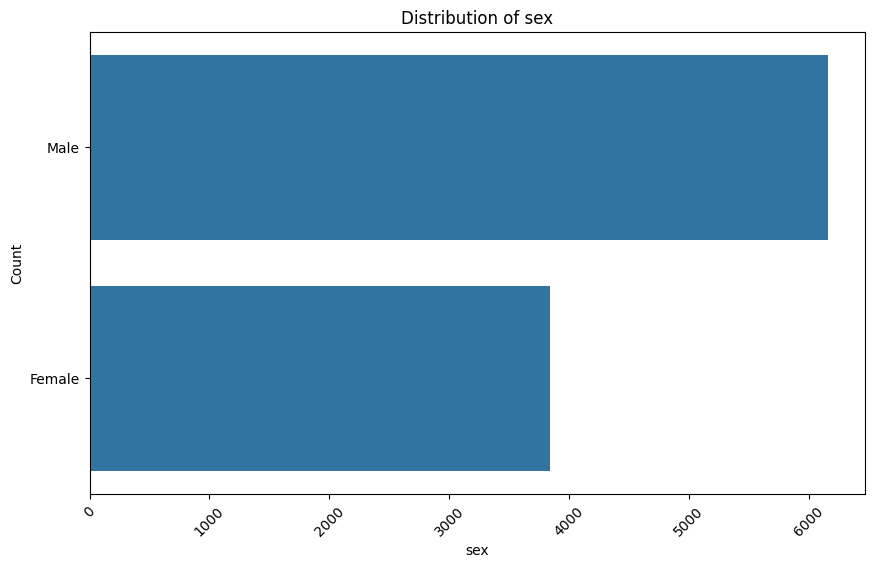

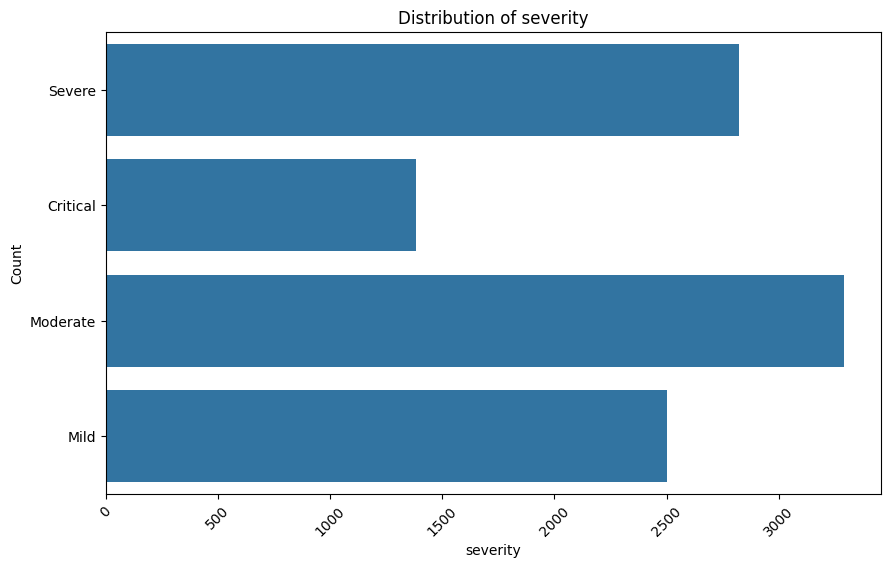

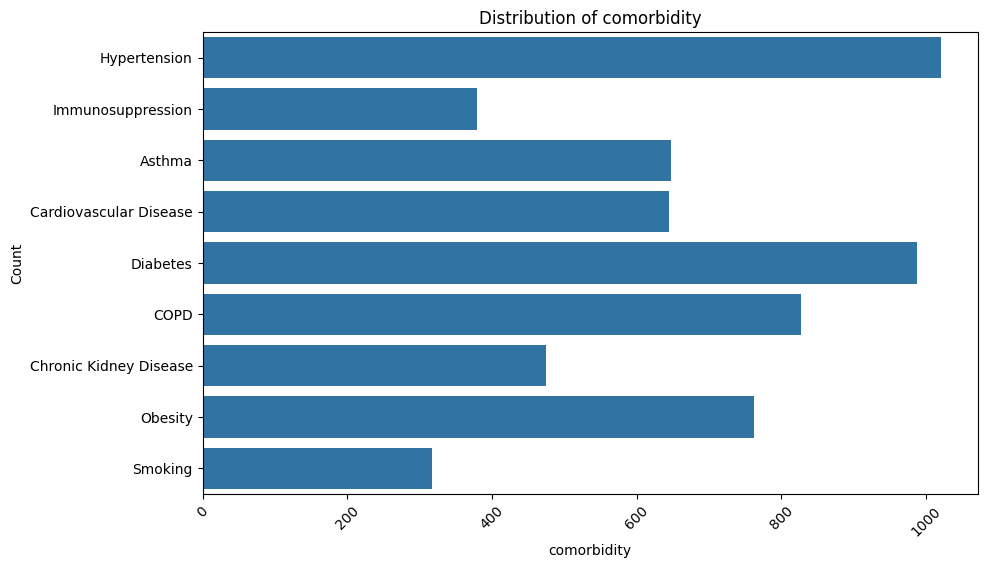

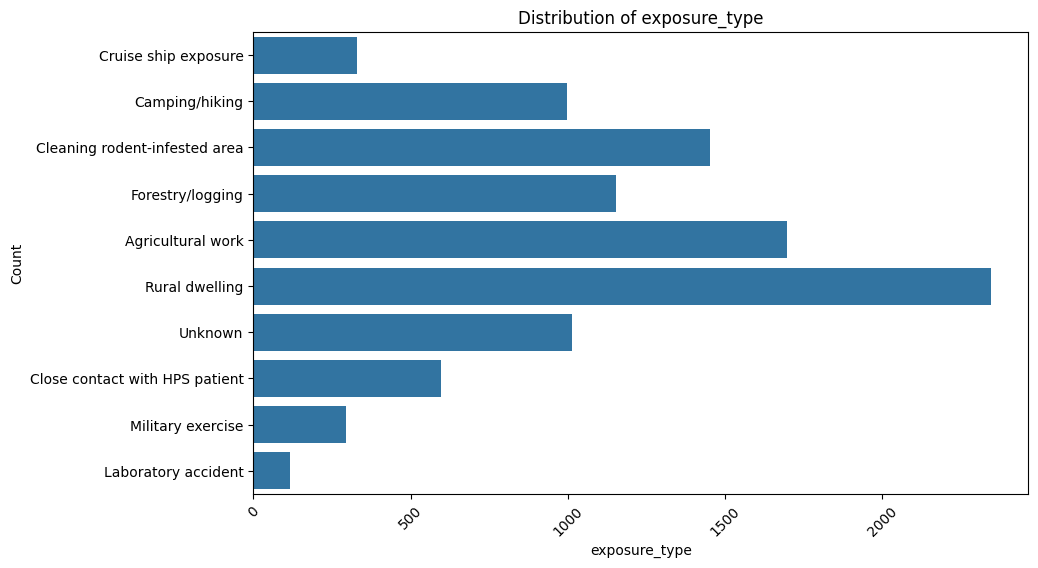

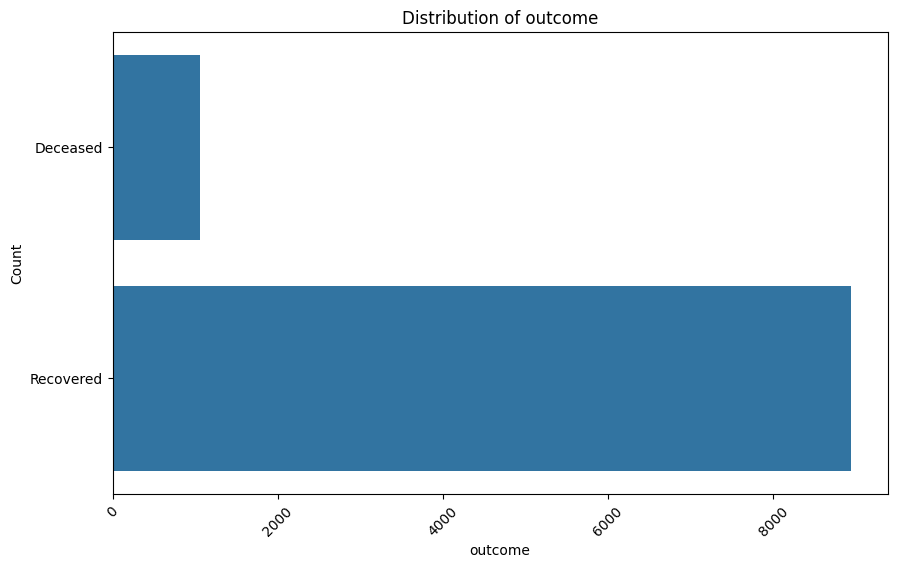

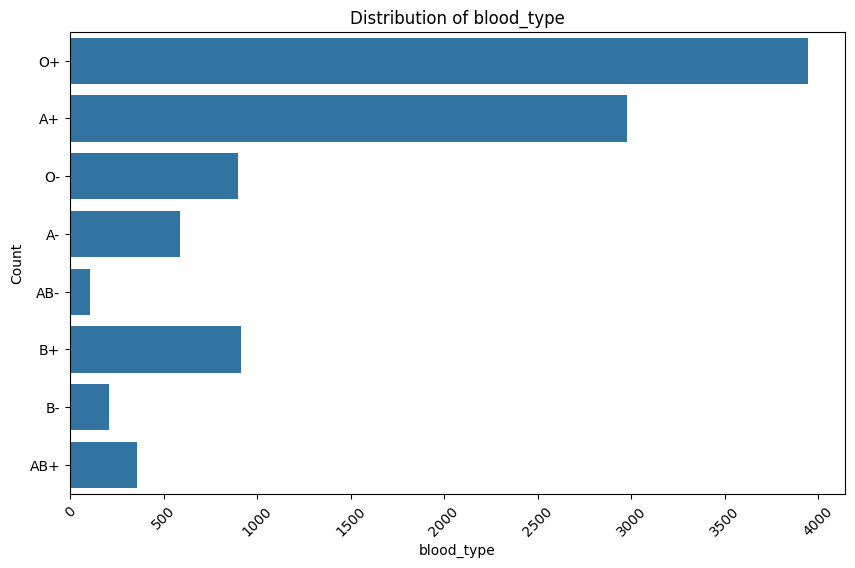

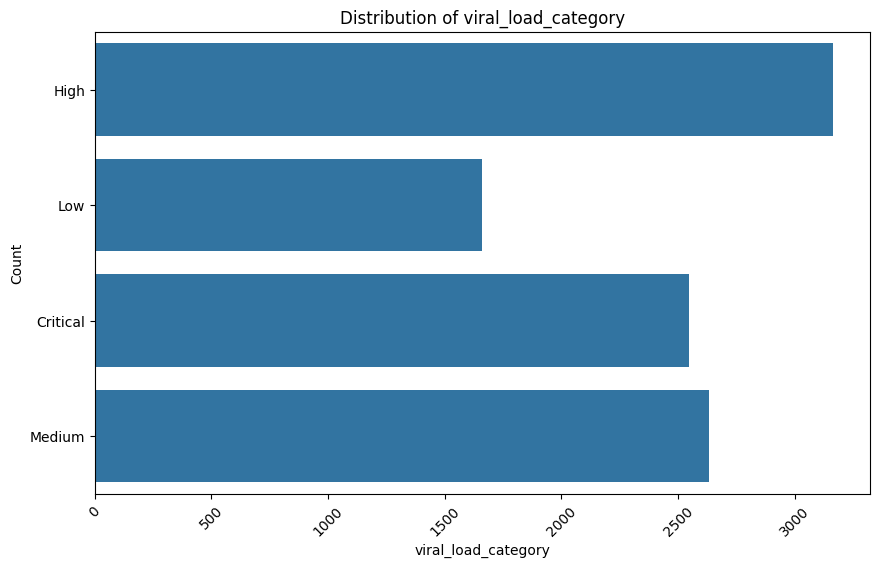

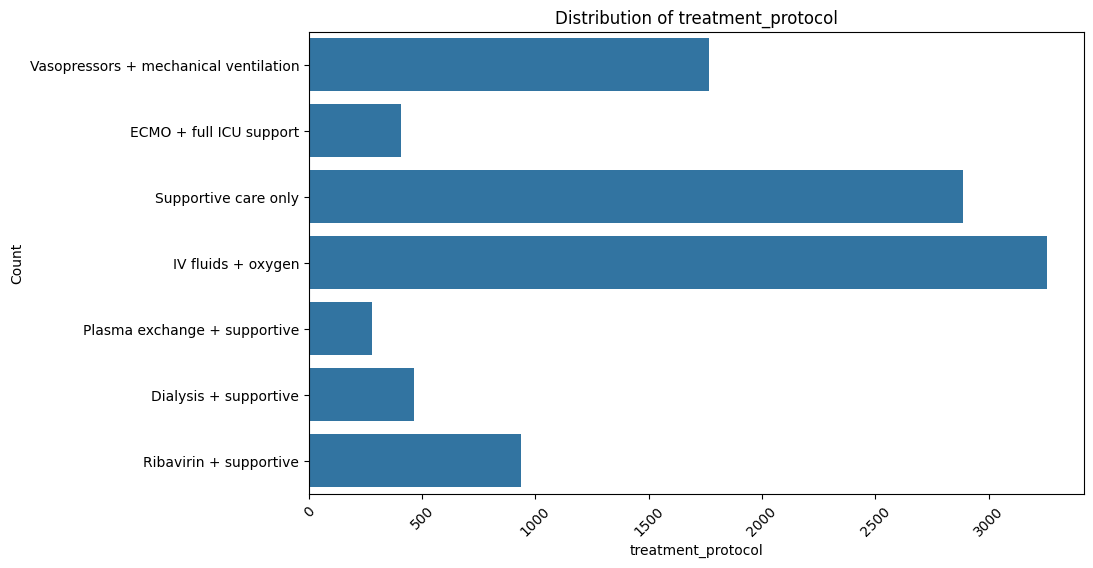

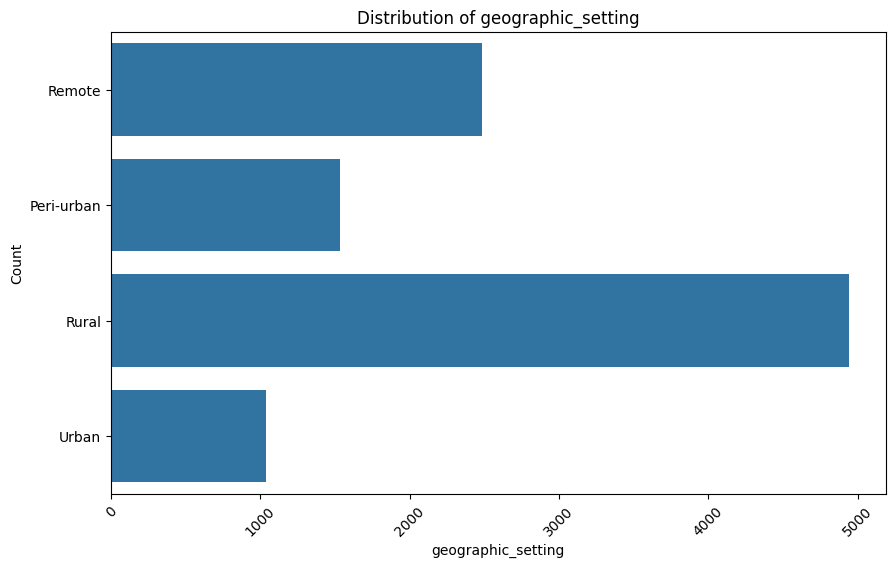

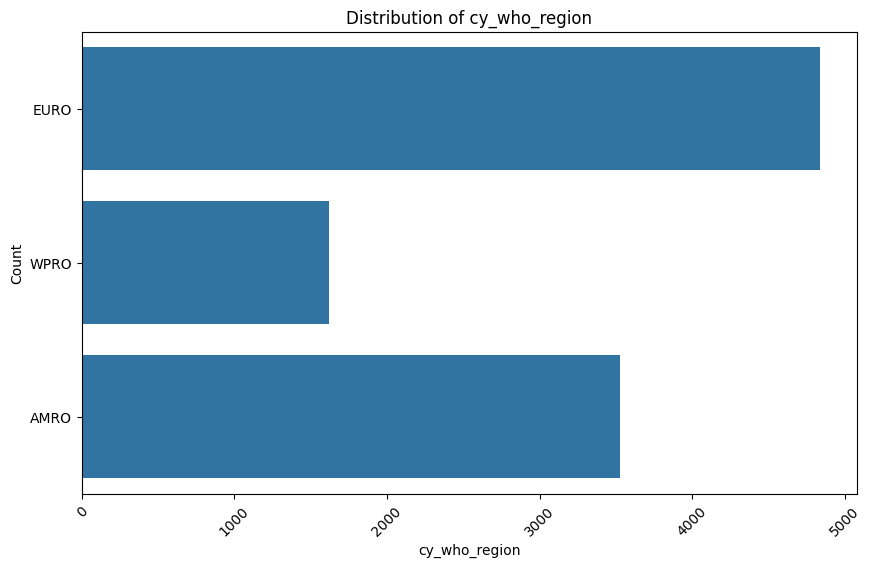

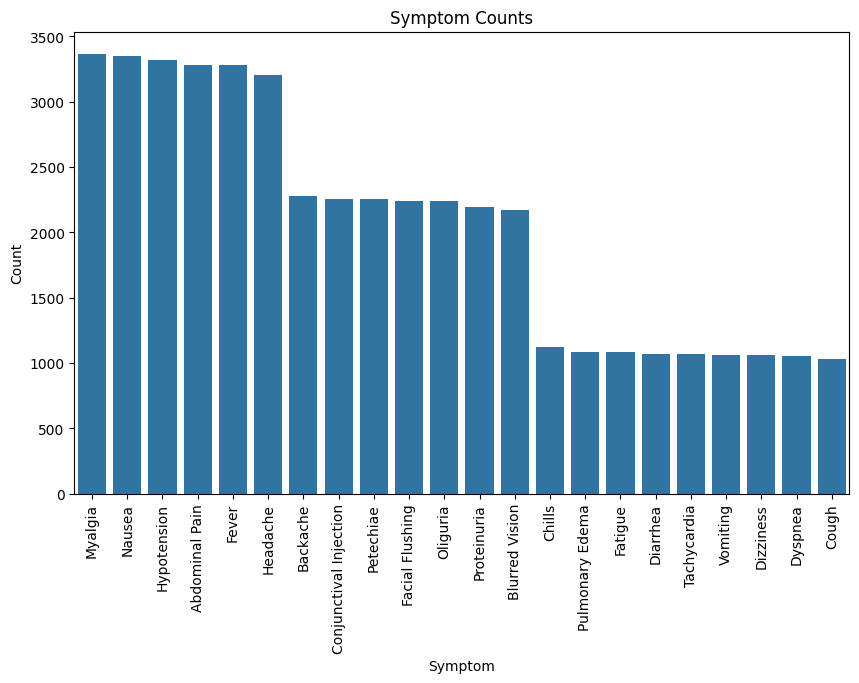

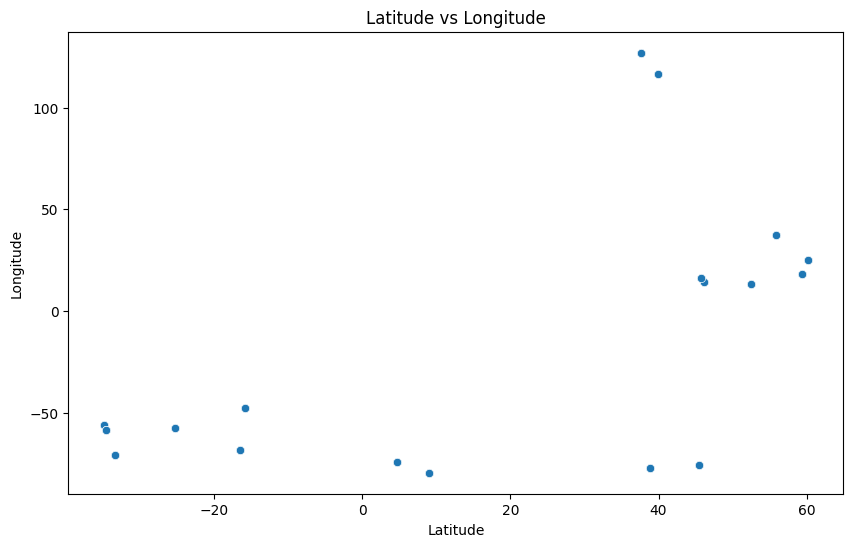

In [36]:
data

numeric_cols = ['age', 'incubation_days', 'length_of_stay_days', 'days_to_diagnosis', 'cy_confirmed_cases', 'cy_deaths', 'cy_recovered', 'cy_case_fatality_rate', 'cy_hospitalized', 'cy_icu_admissions', 'cy_human_to_human_cases', 'avg_temperature', 'avg_precipitation', 'rural_pop_pct', 'urban_pop_pct', 'pop_density', 'gni_per_capita', 'life_expectancy']
categorical_cols = ['country', 'syndrome', 'sex', 'severity', 'comorbidity', 'exposure_type', 'outcome', 'blood_type', 'viral_load_category', 'treatment_protocol', 'geographic_setting', 'cy_who_region', ]

all_symptoms = data['symptoms'].fillna('').str.split(r',\s*').apply(lambda x: [s for s in x if s])
symptom_list = [symptom for row in all_symptoms for symptom in row]
symptom_counts = Counter(symptom_list)

# Plot regular columns
def plot_numerical_distribution(col):
    plt.figure(figsize=(10, 6))
    sns.histplot(data[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

def plot_categorical_distribution(col):
    plt.figure(figsize=(10, 6))
    sns.countplot(data[col])
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

for col in numeric_cols:
    plot_numerical_distribution(col)
for col in categorical_cols:
    plot_categorical_distribution(col)
    
# Plot symptoms
symptom_df = pd.DataFrame.from_dict(symptom_counts, orient='index', columns=['count']).sort_values(by='count', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=symptom_df.index, y='count', data=symptom_df)
plt.title('Symptom Counts')
plt.xlabel('Symptom')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

# Plot latitude longitude scatter
plt.figure(figsize=(10, 6))
sns.scatterplot(x='cy_latitude', y='cy_longitude', data=data)
plt.title('Latitude vs Longitude')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.show()


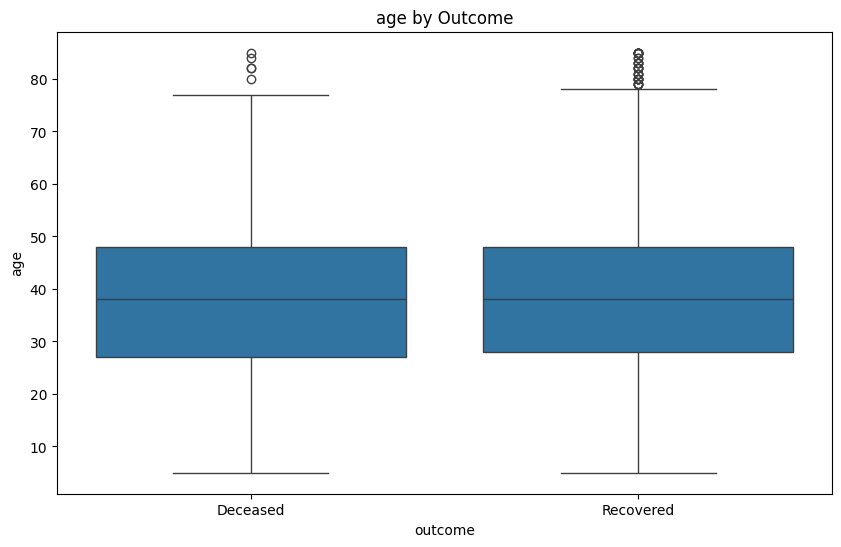

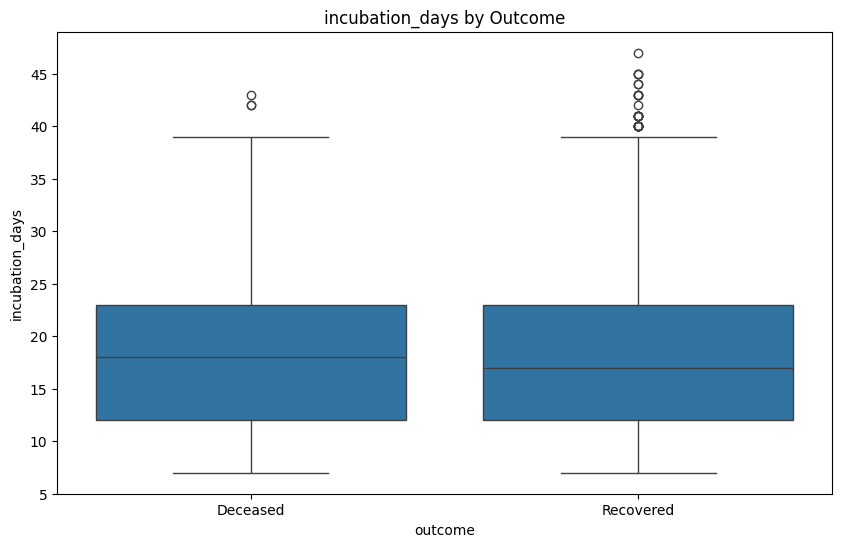

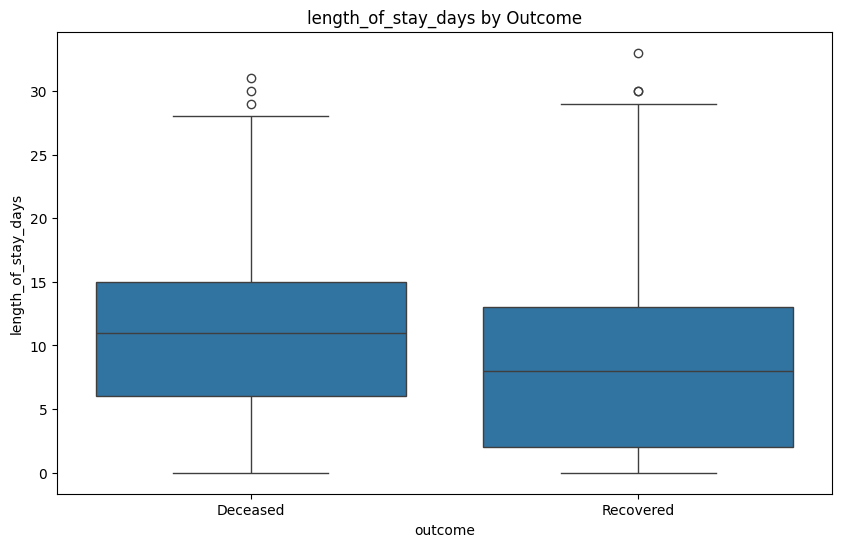

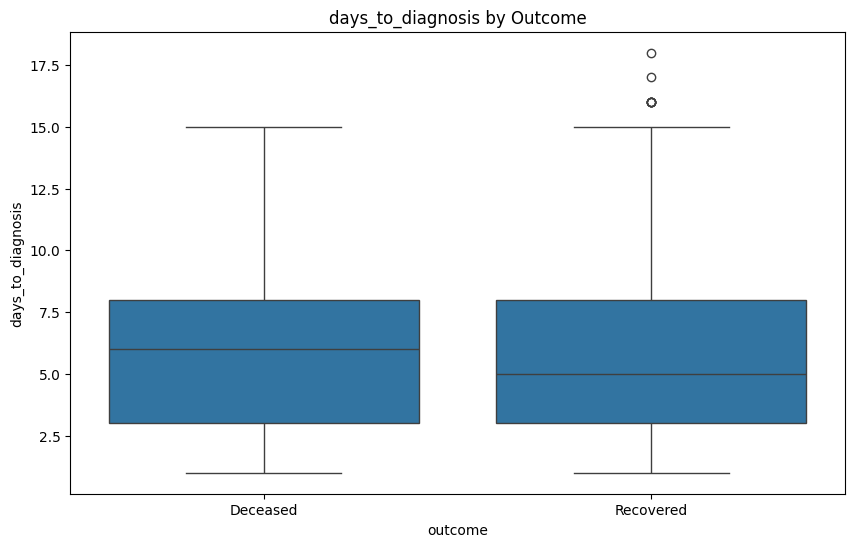

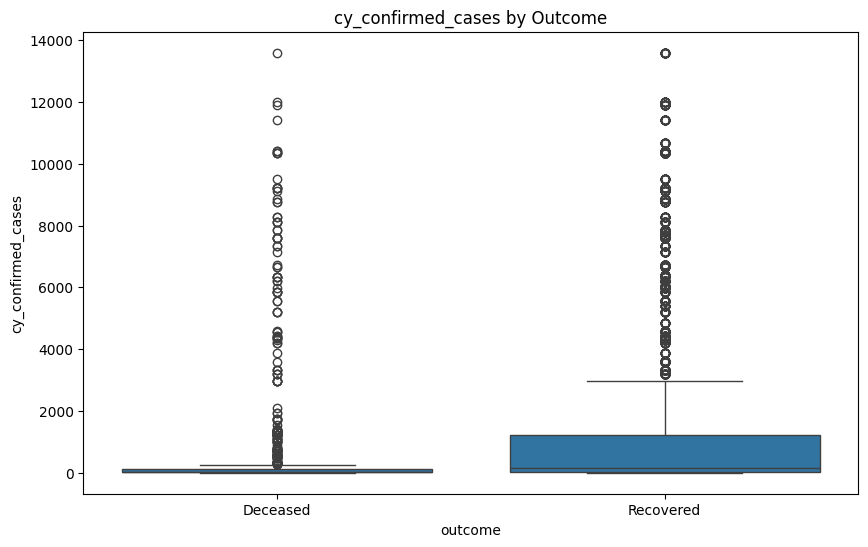

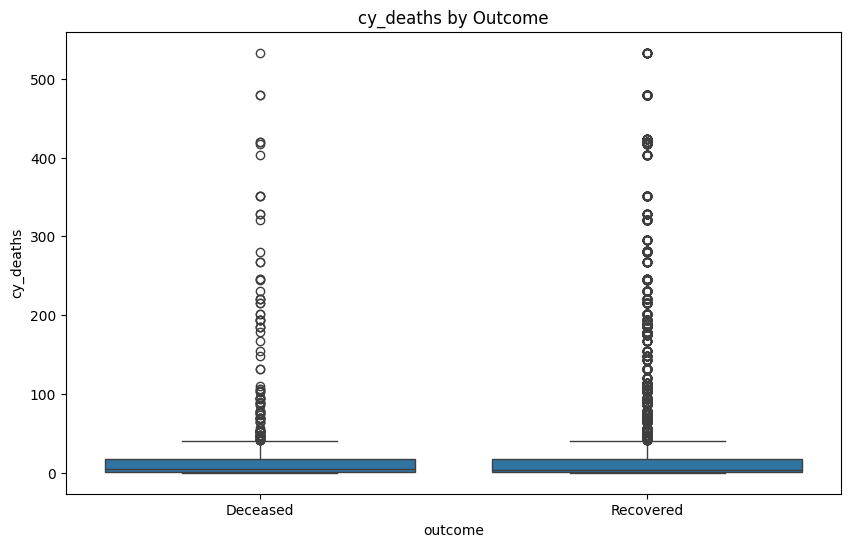

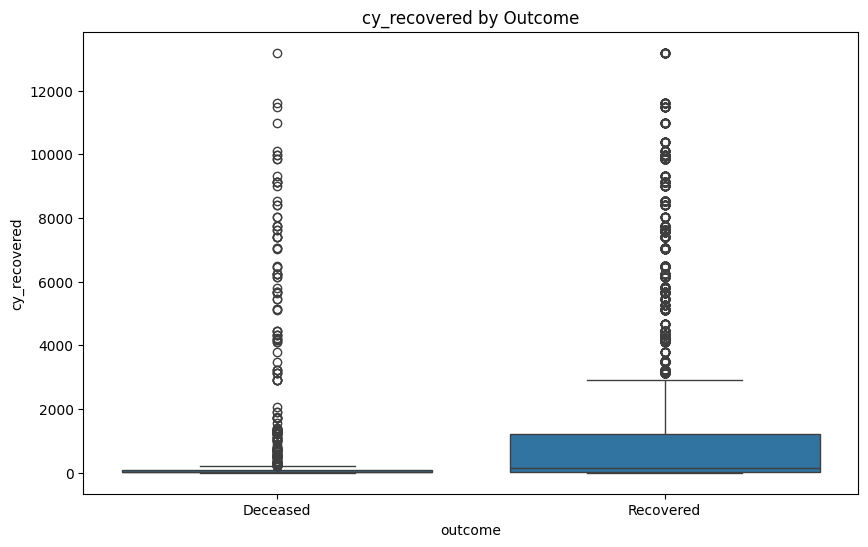

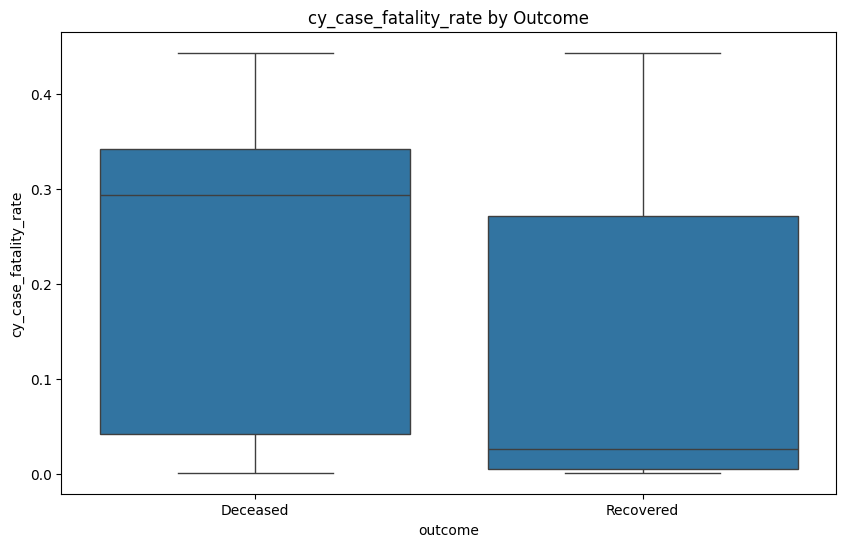

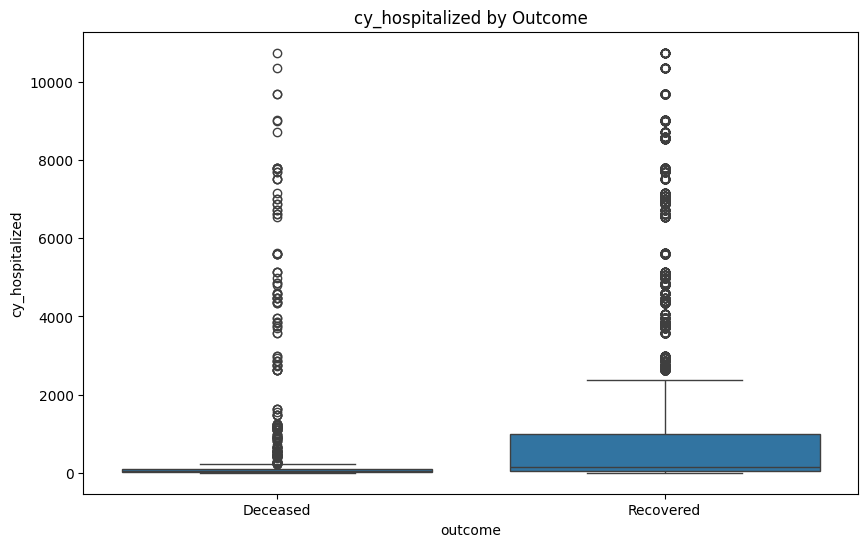

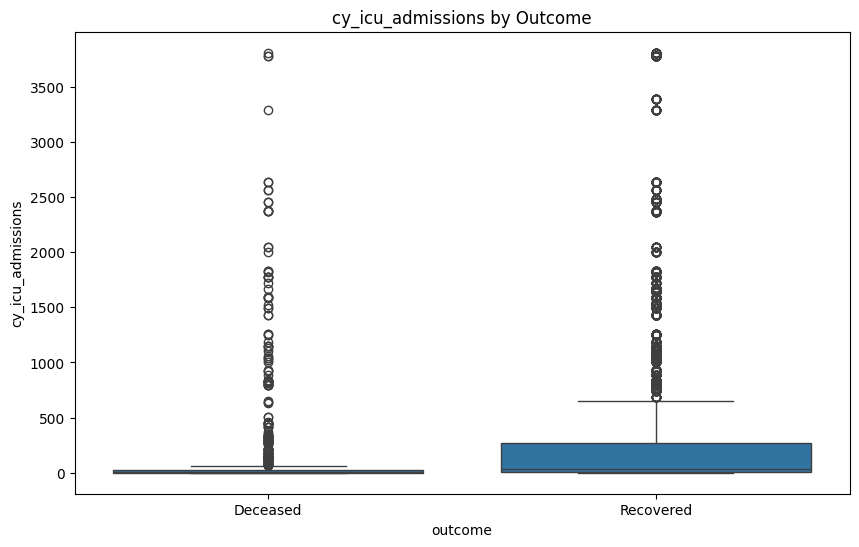

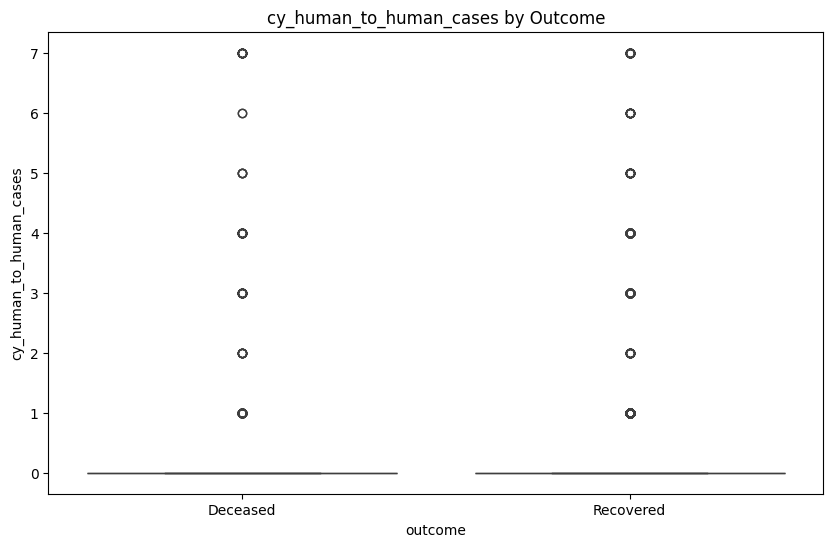

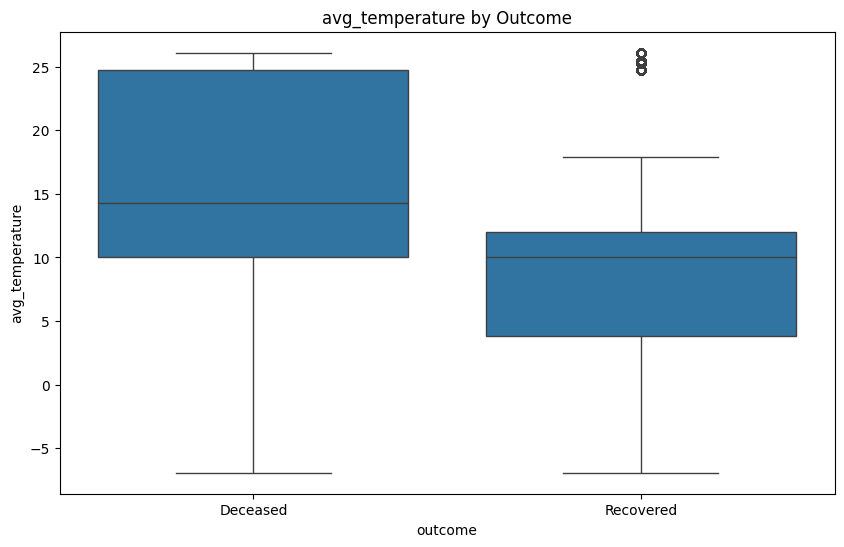

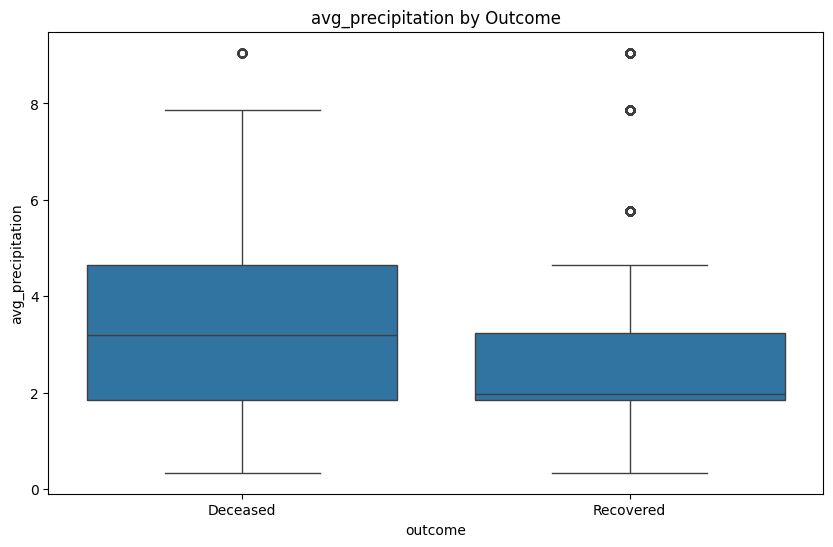

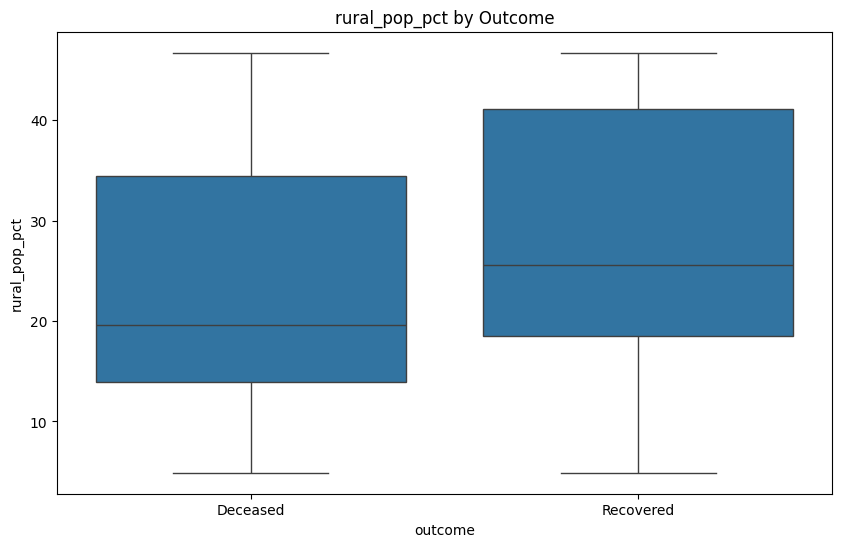

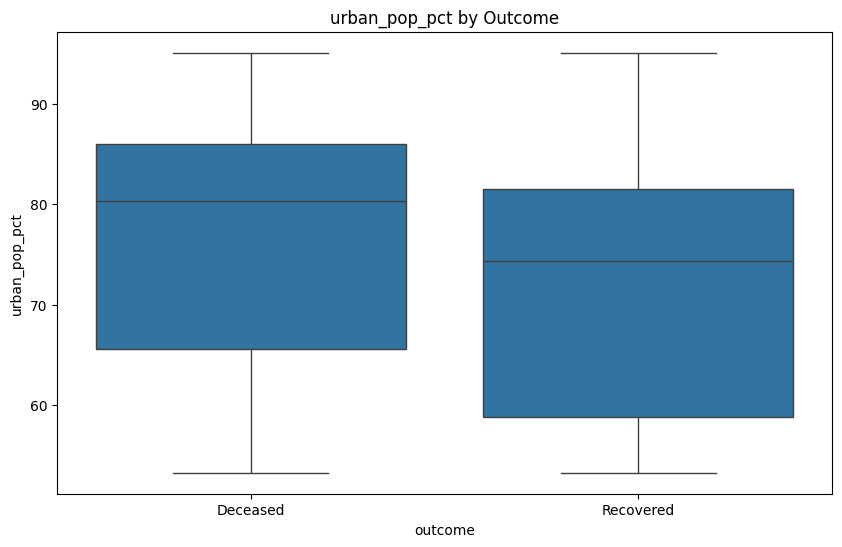

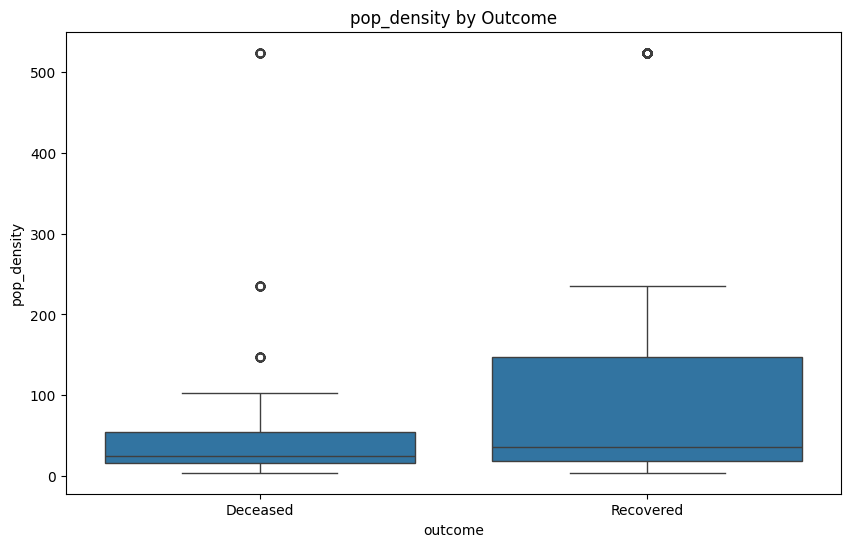

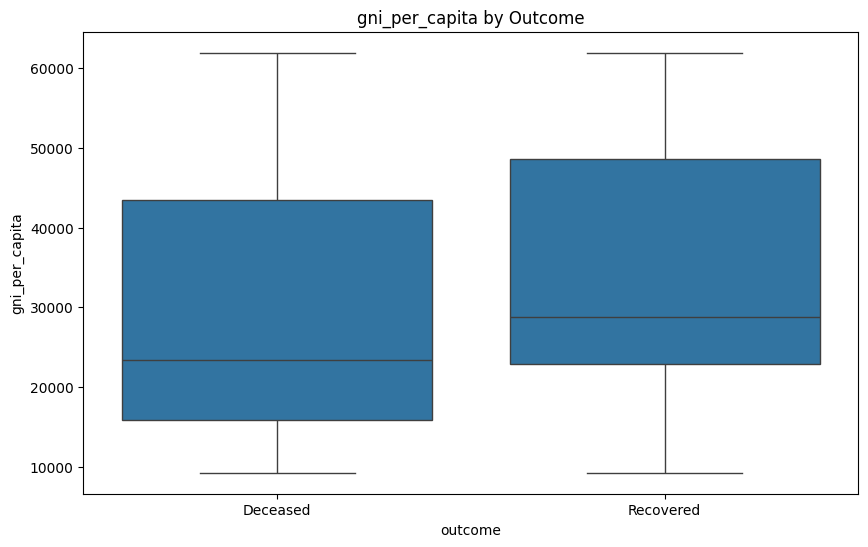

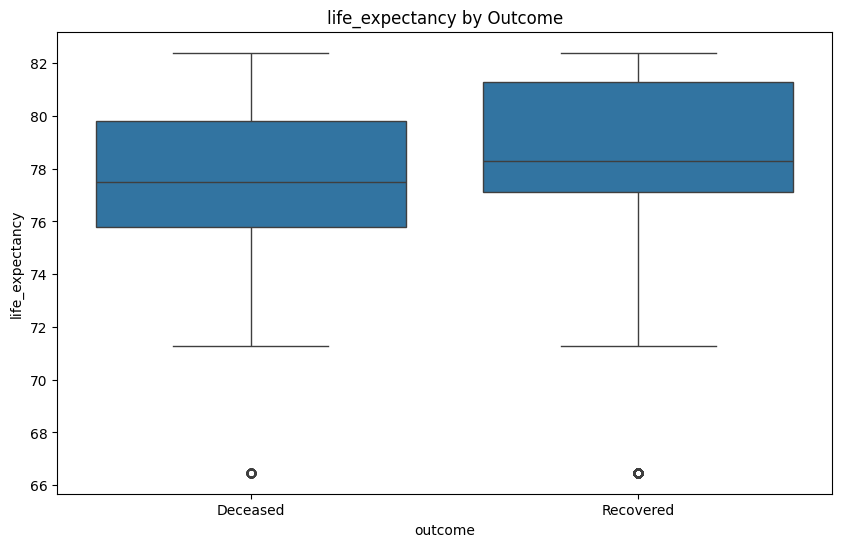

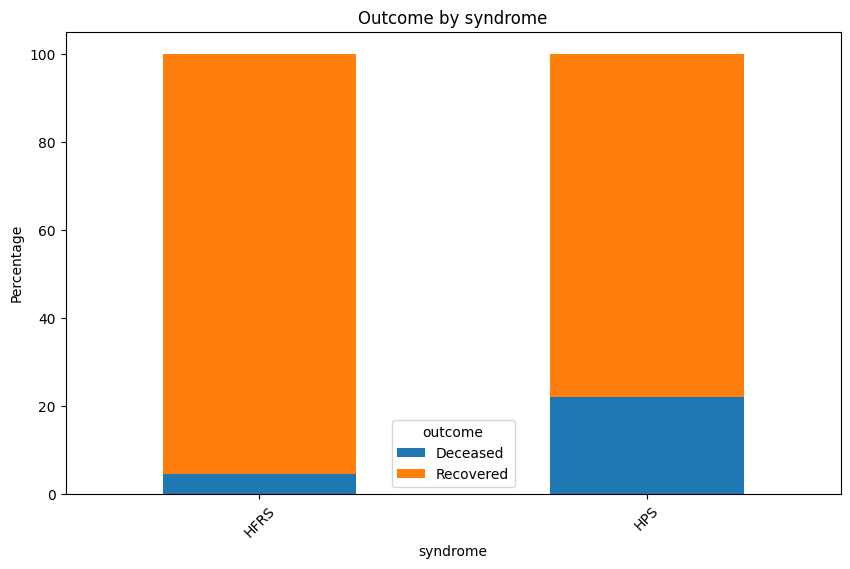

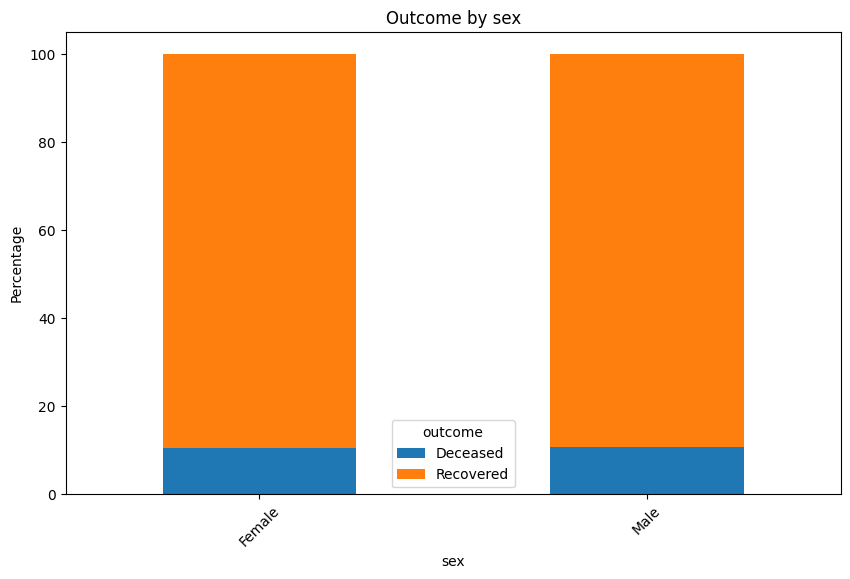

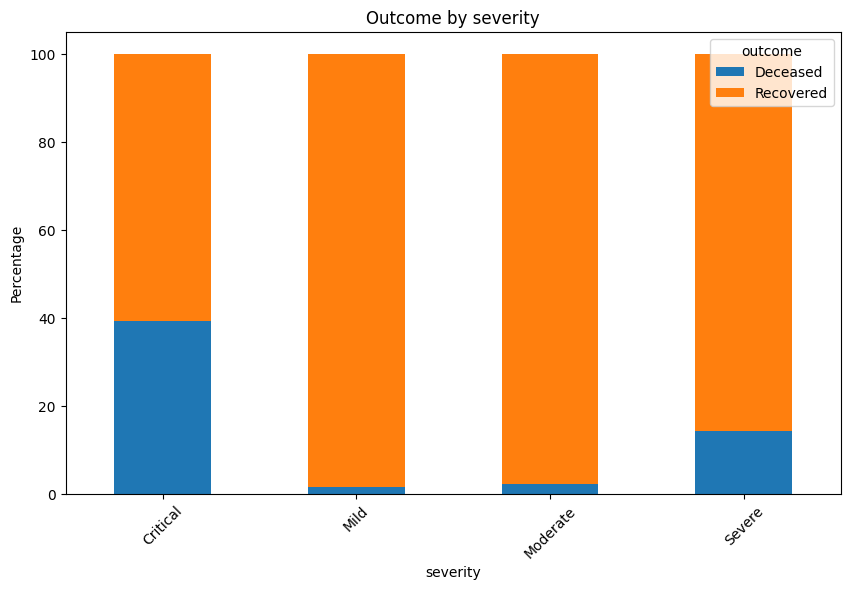

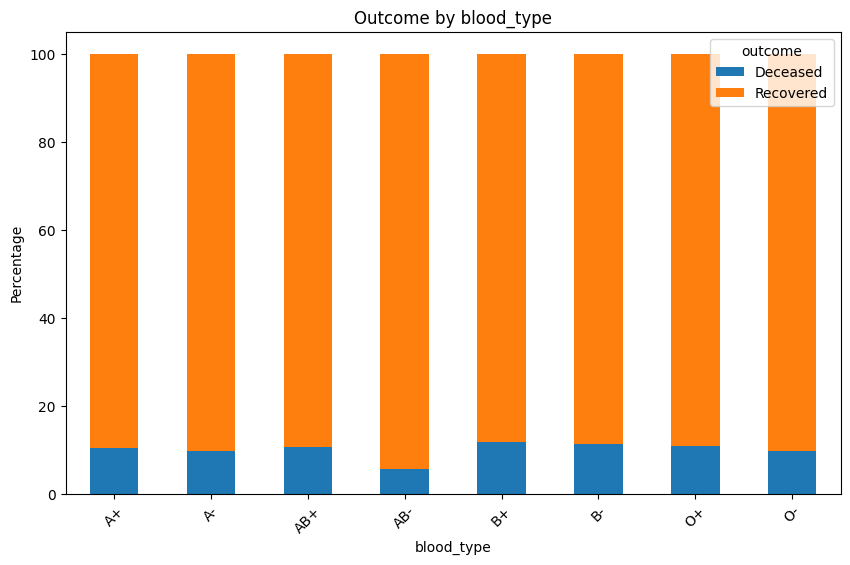

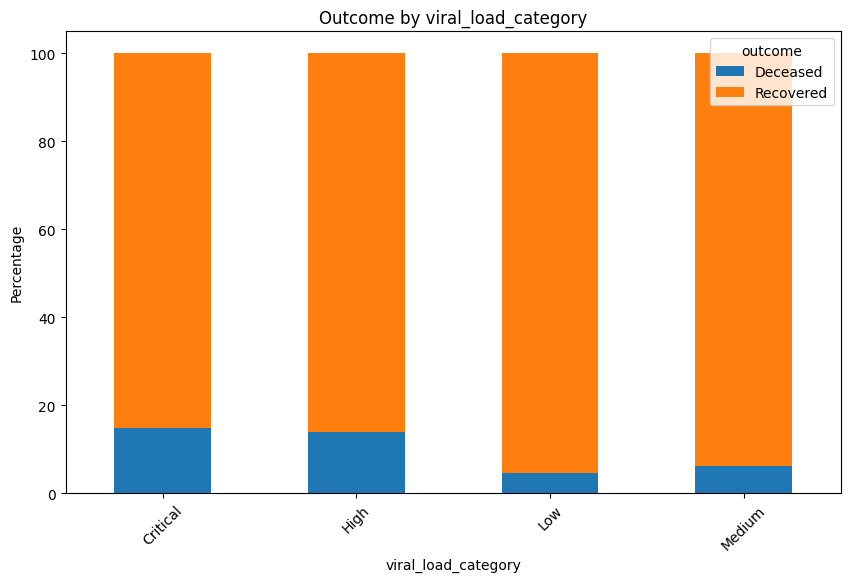

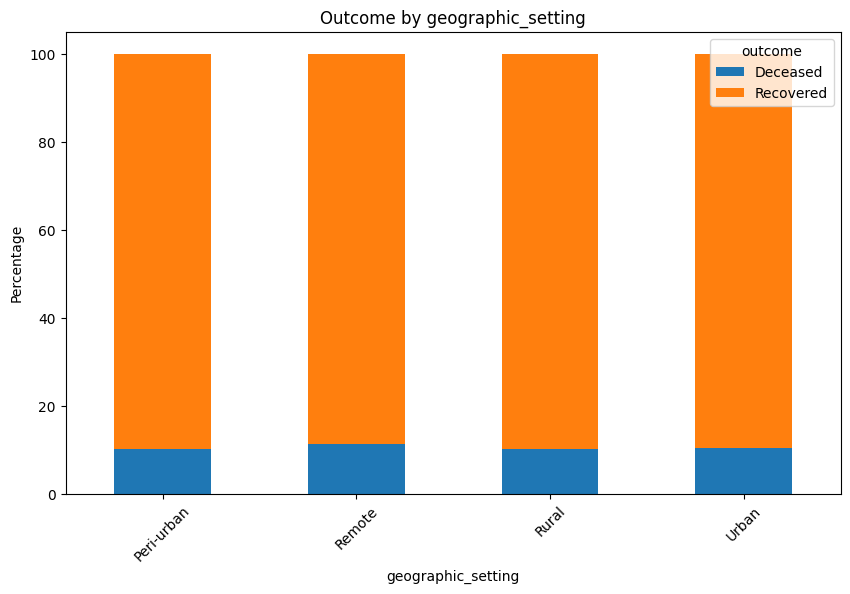

In [37]:
# Numeric features by outcome
for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='outcome', y=col, data=data)
    plt.title(f'{col} by Outcome')
    plt.show()

# Categorical features vs outcome (survival rate per category)
for col in ['syndrome', 'sex', 'severity', 'blood_type', 
            'viral_load_category', 'geographic_setting']:
    ct = pd.crosstab(data[col], data['outcome'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, figsize=(10, 6))
    plt.title(f'Outcome by {col}')
    plt.ylabel('Percentage')
    plt.xticks(rotation=45)
    plt.show()

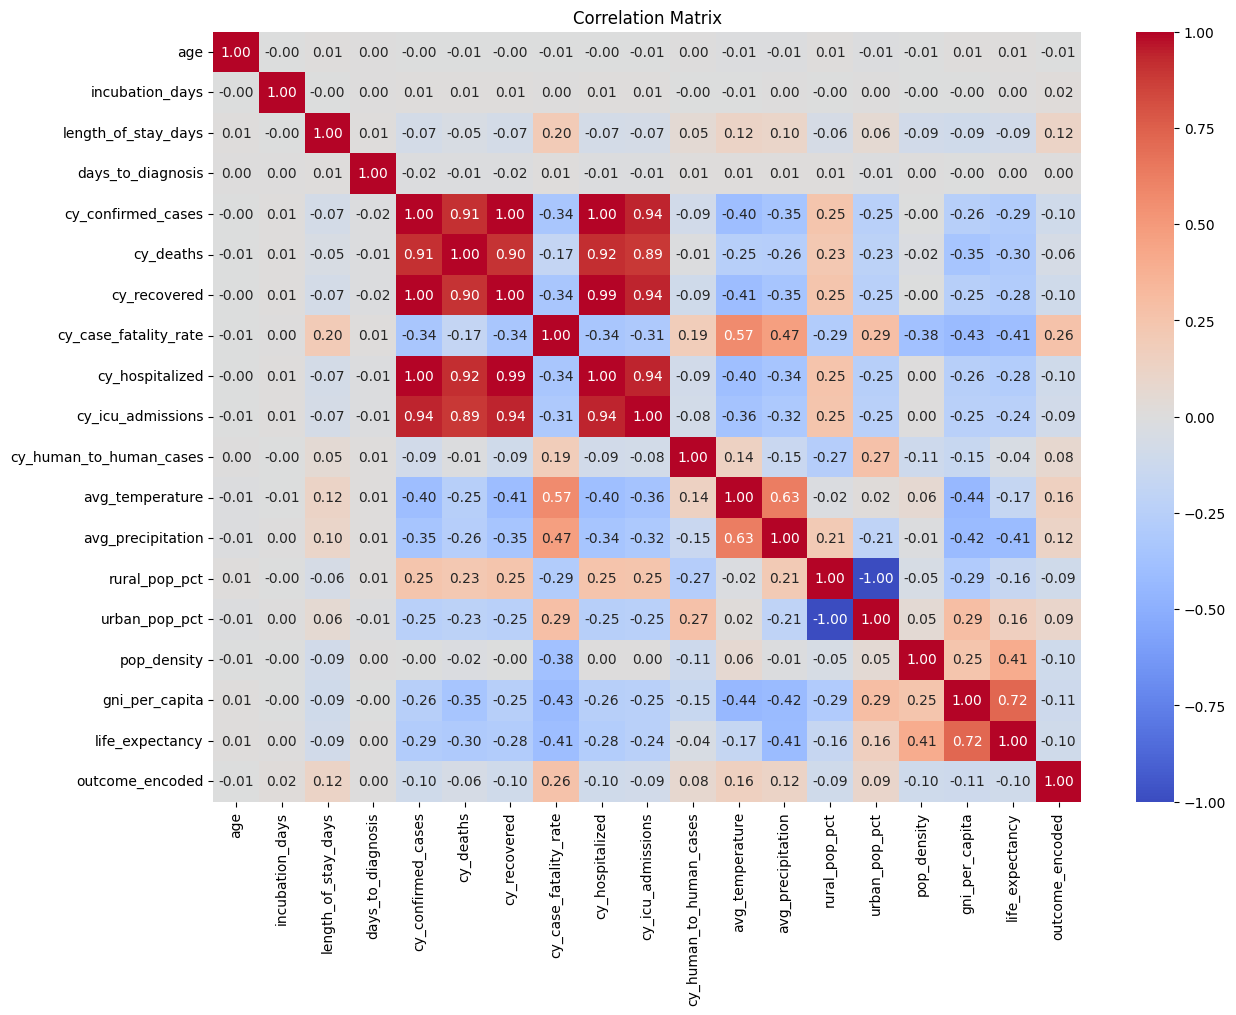

In [38]:
data['outcome_encoded'] = data['outcome'].map({'Recovered': 0, 'Deceased': 1})
plt.figure(figsize=(14, 10))
sns.heatmap(
    data[numeric_cols + ['outcome_encoded']].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0
)
plt.title('Correlation Matrix')
plt.show()

In [39]:
df = data.copy()

# split comma-separated symptoms into lists
df["symptom_list"] = (
    df["symptoms"]
    .fillna("")
    .astype(str)
    .str.split(",")
    .apply(lambda symptoms: [s.strip().lower() for s in symptoms if s.strip()])
)

# multi-label binarize symptoms
mlb = MultiLabelBinarizer()
symptom_matrix = mlb.fit_transform(df["symptom_list"])

symptom_df = pd.DataFrame(
    symptom_matrix,
    columns=mlb.classes_,
    index=df.index
)

# add outcome column
symptom_df["outcome"] = df["outcome"]

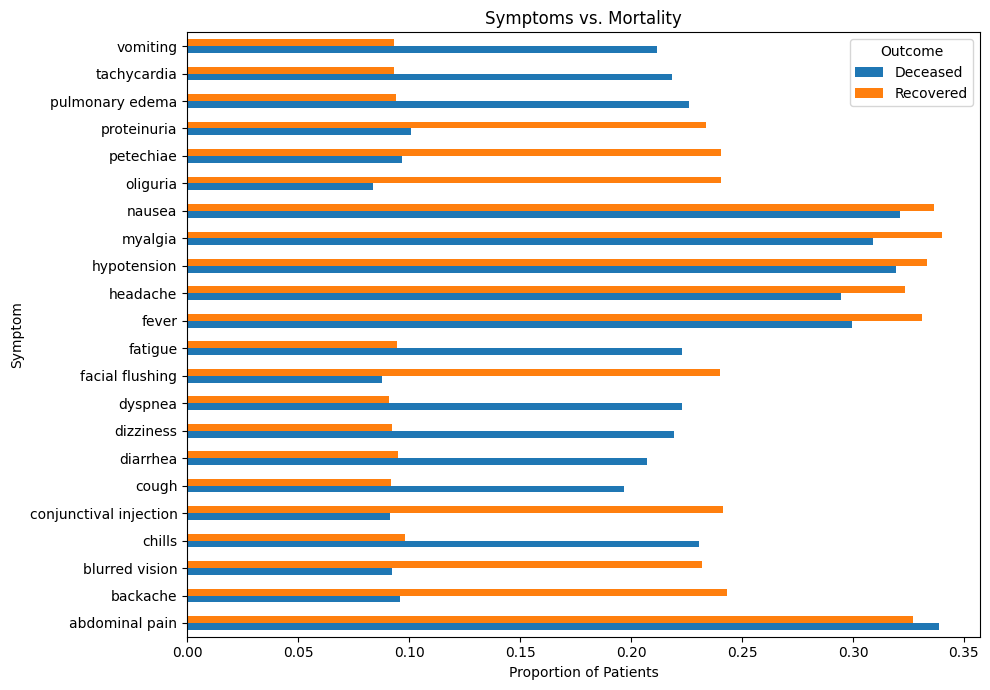

In [40]:
symptom_cols = symptom_df.drop(columns="outcome").columns

symptom_prevalence = symptom_df.groupby("outcome")[symptom_cols].mean().T
symptom_prevalence.plot(kind="barh", figsize=(10, 7))

plt.xlabel("Proportion of Patients")
plt.ylabel("Symptom")
plt.title("Symptoms vs. Mortality")
plt.legend(title="Outcome")
plt.tight_layout()
plt.show()

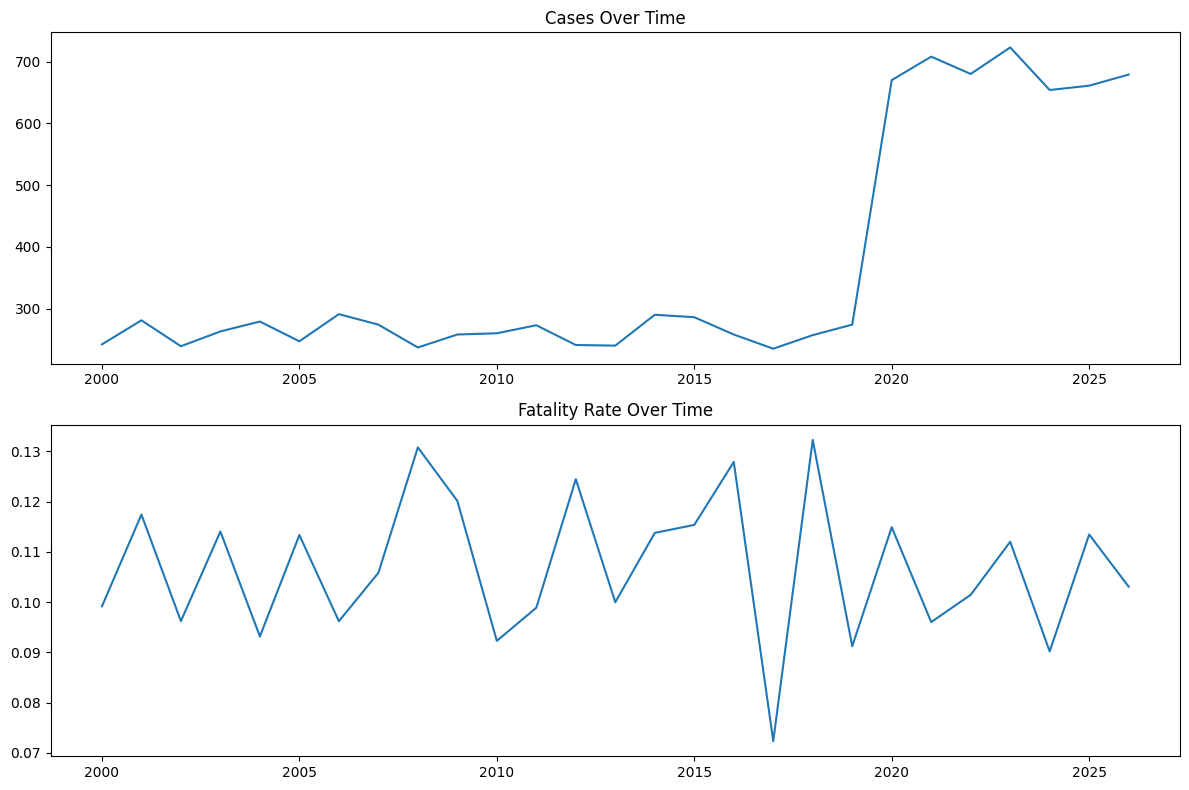

In [41]:
# Cases and deaths over time
yearly = data.groupby('year').agg(
    cases=('outcome', 'count'),
    deaths=('outcome', lambda x: (x == 'Deceased').sum())
).reset_index()
yearly['fatality_rate'] = yearly['deaths'] / yearly['cases']


fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(yearly['year'], yearly['cases'])
axes[0].set_title('Cases Over Time')
axes[1].plot(yearly['year'], yearly['fatality_rate'])
axes[1].set_title('Fatality Rate Over Time')
plt.tight_layout()
plt.show()

# Preprocessing

In [42]:
# Drop erroneous columns

# Drop the WHO region, since we have country level data and latitude/longitude
data = data.drop(columns=["cy_who_region"])

# Drop the cy_isoo3 column, since it is just a repeat of the iso3 column
data = data.drop(columns=["cy_iso3"])

# Drop the country_code column, since it is just a repeat of the iso3 column
data = data.drop(columns=["country_code"])

# Drop the cy_syndrome column, since it is just a repeat of the syndrome column
data = data.drop(columns=["cy_syndrome"])

data

,patient_id,year,country,syndrome,age,sex,symptoms,incubation_days,severity,hospitalized,...,cy_icu_admissions,cy_human_to_human_cases,avg_temperature,avg_precipitation,pop_density,gni_per_capita,life_expectancy,rural_pop_pct,urban_pop_pct,outcome_encoded
0,PT-00001,2026,MV Hondius (International),HPS,82,Male,"Hypotension, Chills, Abdominal Pain, Vomiting,...",22,Severe,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,PT-00002,2026,MV Hondius (International),HPS,73,Female,"Pulmonary Edema, Hypotension, Dyspnea, Cough",13,Severe,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,PT-00003,2026,MV Hondius (International),HPS,62,Female,"Vomiting, Chills, Hypotension, Myalgia, Tachyc...",9,Critical,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,PT-00004,2026,MV Hondius (International),HPS,82,Female,"Diarrhea, Myalgia, Nausea, Chills, Dizziness, ...",21,Critical,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,PT-00005,2026,MV Hondius (International),HPS,74,Male,"Chills, Fever, Pulmonary Edema, Myalgia",12,Severe,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,PT-09996,2025,USA,HPS,37,Female,"Dizziness, Headache, Pulmonary Edema",29,Severe,1,...,8.0,0.0,14.278577,2.239200,35.432118,61941.428571,78.273693,19.617525,80.382475,0
9996,PT-09997,2019,Canada,HPS,58,Female,"Hypotension, Vomiting, Myalgia, Diarrhea, Fati...",20,Severe,1,...,0.0,0.0,-6.929536,1.189878,4.097197,48416.428571,81.659739,18.435541,81.564459,1
9997,PT-09998,2015,Colombia,HPS,21,Female,"Tachycardia, Cough, Dizziness",24,Severe,1,...,0.0,0.0,26.098927,5.775950,43.508530,14565.714286,75.801714,22.659428,77.340572,0
9998,PT-09999,2004,South Korea,HFRS,24,Female,"Petechiae, Headache, Blurred Vision",28,Moderate,1,...,129.0,0.0,11.985690,3.207493,523.839028,43470.714286,82.167247,18.471364,81.528636,0


In [43]:
# Process the symptoms column

# Fill nulls first, then split
data['symptoms'] = data['symptoms'].fillna('').str.split(r',\s*')

# Remove empty strings from lists (artifact of splitting empty strings)
data['symptoms'] = data['symptoms'].apply(lambda x: [s for s in x if s])

# Use MultiLabelBinarizer to one-hot encode the symptoms
mlb = MultiLabelBinarizer()
symptoms_encoded = mlb.fit_transform(data['symptoms'])
data_symptoms = pd.DataFrame(symptoms_encoded, columns=[f'sym_{c}' for c in mlb.classes_])

data = pd.concat([data, data_symptoms], axis=1)
data = data.drop(columns=['symptoms'])

data

,patient_id,year,country,syndrome,age,sex,incubation_days,severity,hospitalized,icu_admission,...,sym_Headache,sym_Hypotension,sym_Myalgia,sym_Nausea,sym_Oliguria,sym_Petechiae,sym_Proteinuria,sym_Pulmonary Edema,sym_Tachycardia,sym_Vomiting
0,PT-00001,2026,MV Hondius (International),HPS,82,Male,22,Severe,1,1,...,0,1,0,0,0,0,0,1,0,1
1,PT-00002,2026,MV Hondius (International),HPS,73,Female,13,Severe,1,0,...,0,1,0,0,0,0,0,1,0,0
2,PT-00003,2026,MV Hondius (International),HPS,62,Female,9,Critical,1,1,...,0,1,1,0,0,0,0,0,1,1
3,PT-00004,2026,MV Hondius (International),HPS,82,Female,21,Critical,1,1,...,1,1,1,1,0,0,0,0,0,0
4,PT-00005,2026,MV Hondius (International),HPS,74,Male,12,Severe,1,1,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,PT-09996,2025,USA,HPS,37,Female,29,Severe,1,1,...,1,0,0,0,0,0,0,1,0,0
9996,PT-09997,2019,Canada,HPS,58,Female,20,Severe,1,1,...,0,1,1,0,0,0,0,0,0,1
9997,PT-09998,2015,Colombia,HPS,21,Female,24,Severe,1,1,...,0,0,0,0,0,0,0,0,1,0
9998,PT-09999,2004,South Korea,HFRS,24,Female,28,Moderate,1,0,...,1,0,0,0,0,1,0,0,0,0


In [44]:
# Do Ordinal Encoding on some categorical features

severity_mapping = {
    'Mild': 0,
    'Moderate': 1,
    'Severe': 2,
    'Critical': 3,
}

data['severity_encoded'] = data['severity'].map(severity_mapping)
data.drop(columns=['severity'], inplace=True)

viral_load_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Critical': 4,
    '': 0  # Assuming empty string means no viral load or unknown
}

data['viral_load_encoded'] = data['viral_load_category'].map(viral_load_mapping)
data.drop(columns=['viral_load_category'], inplace=True)

outcome_mapping = {
    'Recovered': 0,
    'Deceased': 1,
}

data['outcome_encoded'] = data['outcome'].map(outcome_mapping)
data.drop(columns=['outcome'], inplace=True)

data

,patient_id,year,country,syndrome,age,sex,incubation_days,hospitalized,icu_admission,mechanical_ventilation,...,sym_Myalgia,sym_Nausea,sym_Oliguria,sym_Petechiae,sym_Proteinuria,sym_Pulmonary Edema,sym_Tachycardia,sym_Vomiting,severity_encoded,viral_load_encoded
0,PT-00001,2026,MV Hondius (International),HPS,82,Male,22,1,1,0,...,0,0,0,0,0,1,0,1,2,3
1,PT-00002,2026,MV Hondius (International),HPS,73,Female,13,1,0,0,...,0,0,0,0,0,1,0,0,2,1
2,PT-00003,2026,MV Hondius (International),HPS,62,Female,9,1,1,0,...,1,0,0,0,0,0,1,1,3,1
3,PT-00004,2026,MV Hondius (International),HPS,82,Female,21,1,1,1,...,1,1,0,0,0,0,0,0,3,4
4,PT-00005,2026,MV Hondius (International),HPS,74,Male,12,1,1,0,...,1,0,0,0,0,1,0,0,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,PT-09996,2025,USA,HPS,37,Female,29,1,1,0,...,0,0,0,0,0,1,0,0,2,1
9996,PT-09997,2019,Canada,HPS,58,Female,20,1,1,0,...,1,0,0,0,0,0,0,1,2,3
9997,PT-09998,2015,Colombia,HPS,21,Female,24,1,1,0,...,0,0,0,0,0,0,1,0,2,4
9998,PT-09999,2004,South Korea,HFRS,24,Female,28,1,0,0,...,0,0,0,1,0,0,0,0,1,1


In [45]:
# Do OHE encoding on remaining categorical features

# Define a function to OHE encode specified categorical columns
def ohe_encode(df, categorical_cols):
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    ohe_encoded = ohe.fit_transform(df[categorical_cols])
    ohe_df = pd.DataFrame(ohe_encoded, columns=ohe.get_feature_names_out(categorical_cols))
    df = pd.concat([df, ohe_df], axis=1)
    return df


# List of categorical columns to encode
categorical_cols = ['country', 'syndrome', 'sex', 'exposure_type', 'blood_type', 'treatment_protocol', 'geographic_setting', 'comorbidity']

# OHE encode the categorical columns and drop the original columns
data = ohe_encode(data, categorical_cols)
data = data.drop(columns=categorical_cols)

data

,patient_id,year,age,incubation_days,hospitalized,icu_admission,mechanical_ventilation,ecmo_used,dialysis,length_of_stay_days,...,comorbidity_Asthma,comorbidity_COPD,comorbidity_Cardiovascular Disease,comorbidity_Chronic Kidney Disease,comorbidity_Diabetes,comorbidity_Hypertension,comorbidity_Immunosuppression,comorbidity_Obesity,comorbidity_Smoking,comorbidity_nan
0,PT-00001,2026,82,22,1,1,0,0,0,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,PT-00002,2026,73,13,1,0,0,0,0,28,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,PT-00003,2026,62,9,1,1,0,0,0,19,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,PT-00004,2026,82,21,1,1,1,0,0,22,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,PT-00005,2026,74,12,1,1,0,0,0,14,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,PT-09996,2025,37,29,1,1,0,0,0,17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9996,PT-09997,2019,58,20,1,1,0,0,0,10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9997,PT-09998,2015,21,24,1,1,0,0,0,16,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9998,PT-09999,2004,24,28,1,0,0,0,0,15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [46]:
# Set patient_id as index

data = data.set_index('patient_id')
data

,year,age,incubation_days,hospitalized,icu_admission,mechanical_ventilation,ecmo_used,dialysis,length_of_stay_days,days_to_diagnosis,...,comorbidity_Asthma,comorbidity_COPD,comorbidity_Cardiovascular Disease,comorbidity_Chronic Kidney Disease,comorbidity_Diabetes,comorbidity_Hypertension,comorbidity_Immunosuppression,comorbidity_Obesity,comorbidity_Smoking,comorbidity_nan
patient_id,,,,,,,,,,,,,,,,,,,,,
PT-00001,2026,82,22,1,1,0,0,0,6,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
PT-00002,2026,73,13,1,0,0,0,0,28,3,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
PT-00003,2026,62,9,1,1,0,0,0,19,4,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
PT-00004,2026,82,21,1,1,1,0,0,22,5,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PT-00005,2026,74,12,1,1,0,0,0,14,5,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PT-09996,2025,37,29,1,1,0,0,0,17,7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
PT-09997,2019,58,20,1,1,0,0,0,10,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
PT-09998,2015,21,24,1,1,0,0,0,16,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [47]:
# Add an indicator for whether the patient's country has metadata
cy_cols = [col for col in data.columns if 'cy_' in col]
data['has_cy_data'] = (~data[cy_cols].isna().any(axis=1)).astype(int)
data

,year,age,incubation_days,hospitalized,icu_admission,mechanical_ventilation,ecmo_used,dialysis,length_of_stay_days,days_to_diagnosis,...,comorbidity_COPD,comorbidity_Cardiovascular Disease,comorbidity_Chronic Kidney Disease,comorbidity_Diabetes,comorbidity_Hypertension,comorbidity_Immunosuppression,comorbidity_Obesity,comorbidity_Smoking,comorbidity_nan,has_cy_data
patient_id,,,,,,,,,,,,,,,,,,,,,
PT-00001,2026,82,22,1,1,0,0,0,6,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
PT-00002,2026,73,13,1,0,0,0,0,28,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
PT-00003,2026,62,9,1,1,0,0,0,19,4,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
PT-00004,2026,82,21,1,1,1,0,0,22,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
PT-00005,2026,74,12,1,1,0,0,0,14,5,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PT-09996,2025,37,29,1,1,0,0,0,17,7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
PT-09997,2019,58,20,1,1,0,0,0,10,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
PT-09998,2015,21,24,1,1,0,0,0,16,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1


# Modelling

In [48]:
def evaluate_model(model, X_test, y_test, model_name="Model", threshold=0.5):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    recall_died = classification_report(y_test, y_pred, output_dict=True)['1']['recall']
    precision_died = classification_report(y_test, y_pred, output_dict=True)['1']['precision']
    
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Recovered', 'Died'],
        cmap='Blues'
    )
    plt.title(f"{model_name} (threshold={threshold}) — Confusion Matrix")
    plt.show()
    
    return {
        'Model': model_name,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'F1 (macro)': f1_macro,
        'Recall (Died)': recall_died,
        'Precision (Died)': precision_died
    }

## Baseline Model

/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


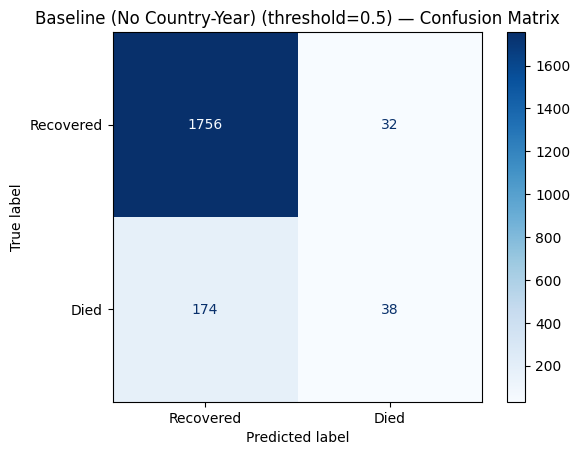

{'Model': 'Baseline (No Country-Year)', 'ROC-AUC': 0.85543033219366, 'PR-AUC': 0.414523388791646, 'F1 (macro)': 0.6070487068850408, 'Recall (Died)': 0.1792452830188679, 'Precision (Died)': 0.5428571428571428}


/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://s

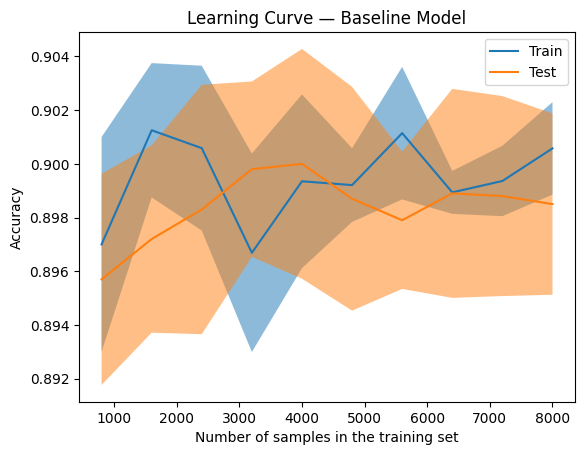

Baseline F2 Score: 0.2070
Baseline MCC Score: 0.2703


In [49]:
# Create a version of the data without the country-year features for comparison
data_no_cy = data[[col for col in data.columns if 'cy_' not in col]]
data_no_cy = data_no_cy.drop(columns=['avg_temperature', 'avg_precipitation', 'rural_pop_pct', 'urban_pop_pct', 'pop_density', 'gni_per_capita', 'life_expectancy'])

# Define X and y for both datasets
X_baseline = data_no_cy.drop(columns=['outcome_encoded'])
y_baseline = data_no_cy['outcome_encoded']

# Train-test split for baseline dataset
X_train_baseline, X_test_baseline, y_train_baseline, y_test_baseline = train_test_split(
    X_baseline, y_baseline, test_size=0.2, random_state=42, stratify=y_baseline
)

# Baseline model training and evaluation
baseline_model = LogisticRegression(random_state=42)
baseline_model.fit(X_train_baseline, y_train_baseline)
y_pred_baseline = baseline_model.predict(X_test_baseline)

# Evaluate baseline model
baseline_model_results = evaluate_model(baseline_model, X_test_baseline, y_test_baseline, model_name="Baseline (No Country-Year)")
print(baseline_model_results)

# Learning curve - accuracy scoring
LearningCurveDisplay.from_estimator(
    baseline_model, X_baseline, y_baseline,
    cv=StratifiedKFold(n_splits=5),
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)
plt.title("Learning Curve — Baseline Model")
plt.show()

# Calculate F2 score and MCC score
y_prob_baseline = baseline_model.predict_proba(X_test_baseline)[:, 1]
y_pred_baseline = (y_prob_baseline >= 0.5).astype(int)
f2_baseline = fbeta_score(y_test_baseline, y_pred_baseline, beta=2)
mcc_baseline = matthews_corrcoef(y_test_baseline, y_pred_baseline)
print(f"Baseline F2 Score: {f2_baseline:.4f}")
print(f"Baseline MCC Score: {mcc_baseline:.4f}")

## Initial Models

In [50]:
X = data.drop(columns=['outcome_encoded'])
y = data['outcome_encoded']

# Train-test split
# Improvement 1: Stratify the split to maintain class balance in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Logistic Regression

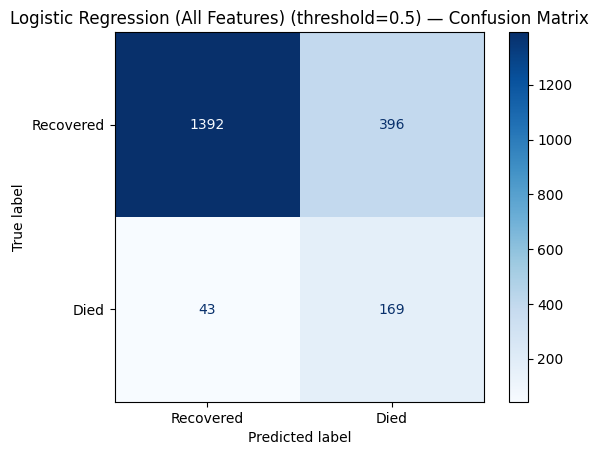

{'Model': 'Logistic Regression (All Features)', 'ROC-AUC': 0.8530190789751383, 'PR-AUC': 0.4119684508299496, 'F1 (macro)': 0.6493989668051101, 'Recall (Died)': 0.7971698113207547, 'Precision (Died)': 0.2991150442477876}


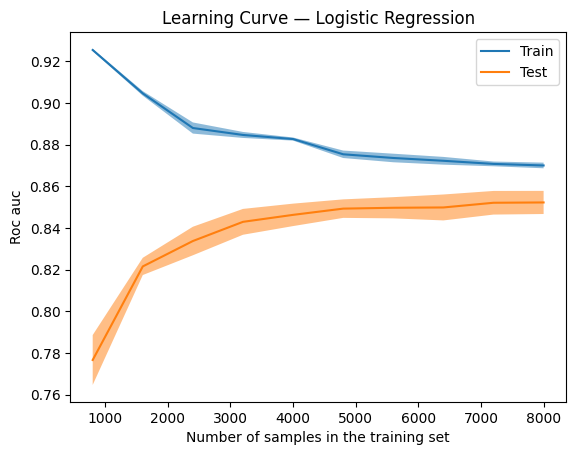

In [51]:
# Model 1: Logistic Regression with all features + high max iterations
pipeline_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42))
])

pipeline_lr.fit(X_train, y_train)
lr_results = evaluate_model(pipeline_lr, X_test, y_test, "Logistic Regression (All Features)")
print(lr_results)

# Learning curve - accuracy scoring
LearningCurveDisplay.from_estimator(
    pipeline_lr, X, y,
    cv=StratifiedKFold(n_splits=5),
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)
plt.title("Learning Curve — Logistic Regression")
plt.show()

In [52]:
def threshold_search(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    
    rows = []
    for threshold in np.arange(0.1, 0.6, 0.05):
        y_pred_thresh = (y_prob >= threshold).astype(int)
        report = classification_report(y_test, y_pred_thresh, output_dict=True, zero_division=0)
        rows.append({
            'Threshold': round(threshold, 2),
            'Recall (Died)': round(report['1']['recall'], 4),
            'Precision (Died)': round(report['1']['precision'], 4),
            'F1 (macro)': round(f1_score(y_test, y_pred_thresh, average='macro'), 4),
            'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4)
        })
    
    return pd.DataFrame(rows)

# Use it
lr_threshold_df = threshold_search(pipeline_lr, X_test, y_test)
lr_threshold_df['Model'] = 'Logistic Regression'
lr_threshold_df = lr_threshold_df.set_index('Model')
lr_threshold_df

,Threshold,Recall (Died),Precision (Died),F1 (macro),ROC-AUC
Model,,,,,
Logistic Regression,0.10,0.9906,0.1505,0.3827,0.853
Logistic Regression,0.15,0.9858,0.1719,0.4500,0.853
Logistic Regression,0.20,0.9764,0.1867,0.4874,0.853
Logistic Regression,0.25,0.9575,0.1975,0.5126,0.853
Logistic Regression,0.30,0.8915,0.2061,0.5366,0.853
Logistic Regression,0.35,0.8679,0.2238,0.5657,0.853
Logistic Regression,0.40,0.8302,0.2455,0.5955,0.853
Logistic Regression,0.45,0.8113,0.2739,0.6263,0.853
Logistic Regression,0.50,0.7972,0.2991,0.6494,0.853


In [53]:
# F2 score and MCC score at 0.5 threshold
y_prob_lr = pipeline_lr.predict_proba(X_test)[:, 1]
y_pred_lr = (y_prob_lr >= 0.5).astype(int)
f2_lr = fbeta_score(y_test, y_pred_lr, beta=2)
mcc_lr = matthews_corrcoef(y_test, y_pred_lr)
print(f"Logistic Regression F2 Score: {f2_lr:.4f}")
print(f"Logistic Regression MCC Score: {mcc_lr:.4f}")

Logistic Regression F2 Score: 0.5980
Logistic Regression MCC Score: 0.3936


### Random Forest

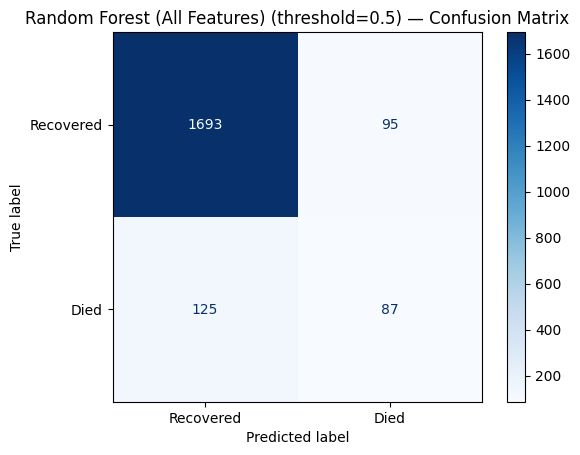

{'Model': 'Random Forest (All Features)', 'ROC-AUC': 0.8576912118526021, 'PR-AUC': 0.39700321980853603, 'F1 (macro)': 0.6903074683761694, 'Recall (Died)': 0.41037735849056606, 'Precision (Died)': 0.47802197802197804}


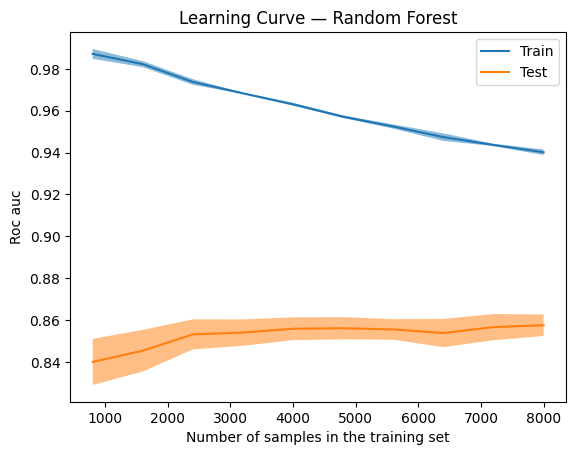

In [54]:
# Model 2: Random Forest with all features + SMOTE for class imbalance + restricted tree depth to prevent overfitting
pipeline_rf = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_rf.fit(X_train, y_train)
rf_results = evaluate_model(pipeline_rf, X_test, y_test, "Random Forest (All Features)")
print(rf_results)

# Learning curve - accuracy scoring
LearningCurveDisplay.from_estimator(
    pipeline_rf, X, y,
    cv=StratifiedKFold(n_splits=5),
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)
plt.title("Learning Curve — Random Forest")
plt.show()

In [55]:
def threshold_search(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    
    rows = []
    for threshold in np.arange(0.1, 0.6, 0.05):
        y_pred_thresh = (y_prob >= threshold).astype(int)
        report = classification_report(y_test, y_pred_thresh, output_dict=True, zero_division=0)
        rows.append({
            'Threshold': round(threshold, 2),
            'Recall (Died)': round(report['1']['recall'], 4),
            'Precision (Died)': round(report['1']['precision'], 4),
            'F1 (macro)': round(f1_score(y_test, y_pred_thresh, average='macro'), 4),
            'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4)
        })
    
    return pd.DataFrame(rows)

# Use it
rf_threshold_df = threshold_search(pipeline_rf, X_test, y_test)
rf_threshold_df['Model'] = 'Random Forest'
rf_threshold_df = rf_threshold_df.set_index('Model')
rf_threshold_df

,Threshold,Recall (Died),Precision (Died),F1 (macro),ROC-AUC
Model,,,,,
Random Forest,0.10,0.9623,0.1903,0.4976,0.8577
Random Forest,0.15,0.8538,0.2207,0.5625,0.8577
Random Forest,0.20,0.8066,0.2697,0.6222,0.8577
Random Forest,0.25,0.7736,0.3015,0.6510,0.8577
Random Forest,0.30,0.7311,0.3277,0.6697,0.8577
Random Forest,0.35,0.6651,0.3543,0.6828,0.8577
Random Forest,0.40,0.5519,0.3887,0.6881,0.8577
Random Forest,0.45,0.4811,0.4286,0.6920,0.8577
Random Forest,0.50,0.4104,0.4780,0.6903,0.8577


In [56]:
# F2 score and MCC score at 0.5 threshold
y_prob_rf = pipeline_rf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf >= 0.5).astype(int)
f2_rf = fbeta_score(y_test, y_pred_rf, beta=2)
mcc_rf = matthews_corrcoef(y_test, y_pred_rf)
print(f"Random Forest F2 Score: {f2_rf:.4f}")
print(f"Random Forest MCC Score: {mcc_rf:.4f}")

Random Forest F2 Score: 0.4223
Random Forest MCC Score: 0.3824


### XGBoost

/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [21:53:14] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1779358231041/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


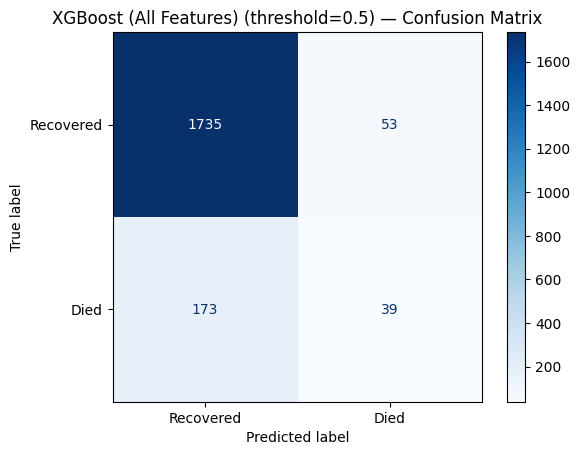

{'Model': 'XGBoost (All Features)', 'ROC-AUC': 0.8429282216875608, 'PR-AUC': 0.3568668553548754, 'F1 (macro)': 0.5977158806106174, 'Recall (Died)': 0.18396226415094338, 'Precision (Died)': 0.42391304347826086}


/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [21:53:15] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1779358231041/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [21:53:15] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1779358231041/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [21:53:15] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1779358231041/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib

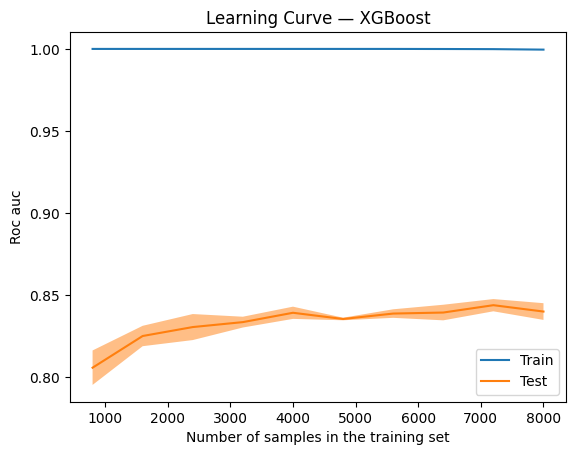

In [57]:
pipeline_xgb = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_xgb.fit(X_train, y_train)
xgb_results = evaluate_model(pipeline_xgb, X_test, y_test, "XGBoost (All Features)")
print(xgb_results)

# Learning curve - accuracy scoring
LearningCurveDisplay.from_estimator(
    pipeline_xgb, X, y,
    cv=StratifiedKFold(n_splits=5),
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)
plt.title("Learning Curve — XGBoost")
plt.show()

In [58]:
def threshold_search(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    
    rows = []
    for threshold in np.arange(0.1, 0.6, 0.05):
        y_pred_thresh = (y_prob >= threshold).astype(int)
        report = classification_report(y_test, y_pred_thresh, output_dict=True, zero_division=0)
        rows.append({
            'Threshold': round(threshold, 2),
            'Recall (Died)': round(report['1']['recall'], 4),
            'Precision (Died)': round(report['1']['precision'], 4),
            'F1 (macro)': round(f1_score(y_test, y_pred_thresh, average='macro'), 4),
            'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4)
        })
    
    return pd.DataFrame(rows)

# Use it
xgb_threshold_df = threshold_search(pipeline_xgb, X_test, y_test)
xgb_threshold_df['Model'] = 'XGBoost'
xgb_threshold_df = xgb_threshold_df.set_index('Model')
xgb_threshold_df

,Threshold,Recall (Died),Precision (Died),F1 (macro),ROC-AUC
Model,,,,,
XGBoost,0.10,0.6934,0.3031,0.6499,0.8429
XGBoost,0.15,0.5755,0.3437,0.6681,0.8429
XGBoost,0.20,0.5094,0.3763,0.6760,0.8429
XGBoost,0.25,0.4670,0.4213,0.6864,0.8429
XGBoost,0.30,0.4104,0.4394,0.6793,0.8429
XGBoost,0.35,0.3726,0.4566,0.6738,0.8429
XGBoost,0.40,0.2972,0.4532,0.6487,0.8429
XGBoost,0.45,0.2406,0.4595,0.6278,0.8429
XGBoost,0.50,0.1840,0.4239,0.5977,0.8429


In [59]:
# F2 score and MCC score at 0.5 threshold
y_prob_xgb = pipeline_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)
f2_xgb = fbeta_score(y_test, y_pred_xgb, beta=2)
mcc_xgb = matthews_corrcoef(y_test, y_pred_xgb)
print(f"XGBoost F2 Score: {f2_xgb:.4f}")
print(f"XGBoost MCC Score: {mcc_xgb:.4f}")

XGBoost F2 Score: 0.2074
XGBoost MCC Score: 0.2268


### LightGBM

/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


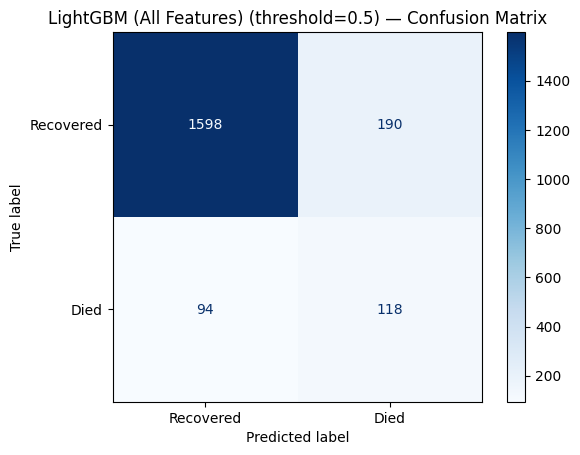

{'Model': 'LightGBM (All Features)', 'ROC-AUC': 0.8526180828162593, 'PR-AUC': 0.3718386123425039, 'F1 (macro)': 0.6861184792219275, 'Recall (Died)': 0.5566037735849056, 'Precision (Died)': 0.38311688311688313}


/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/utils/validation.

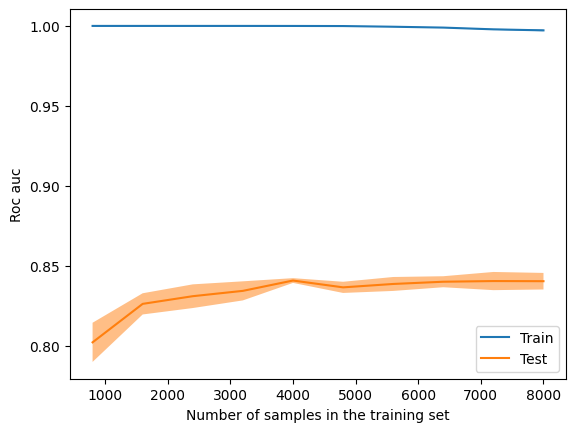

In [60]:
pipeline_lgbm = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', LGBMClassifier(
        class_weight='balanced',
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

pipeline_lgbm.fit(X_train, y_train)
lgbm_results = evaluate_model(pipeline_lgbm, X_test, y_test, "LightGBM (All Features)")
print(lgbm_results)

# Learning curve - accuracy scoring
LearningCurveDisplay.from_estimator(
    pipeline_lgbm, X, y,
    cv=StratifiedKFold(n_splits=5),
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

In [61]:
def threshold_search(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    
    rows = []
    for threshold in np.arange(0.1, 0.6, 0.05):
        y_pred_thresh = (y_prob >= threshold).astype(int)
        report = classification_report(y_test, y_pred_thresh, output_dict=True, zero_division=0)
        rows.append({
            'Threshold': round(threshold, 2),
            'Recall (Died)': round(report['1']['recall'], 4),
            'Precision (Died)': round(report['1']['precision'], 4),
            'F1 (macro)': round(f1_score(y_test, y_pred_thresh, average='macro'), 4),
            'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4)
        })
    
    return pd.DataFrame(rows)

# Use it
lgbm_threshold_df = threshold_search(pipeline_lgbm, X_test, y_test)
lgbm_threshold_df['Model'] = 'LightGBM'
lgbm_threshold_df = lgbm_threshold_df.set_index('Model')
lgbm_threshold_df

/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Threshold,Recall (Died),Precision (Died),F1 (macro),ROC-AUC
Model,,,,,
LightGBM,0.10,0.8962,0.2246,0.5644,0.8526
LightGBM,0.15,0.8491,0.2521,0.6023,0.8526
LightGBM,0.20,0.7877,0.2707,0.6234,0.8526
LightGBM,0.25,0.7500,0.2880,0.6392,0.8526
LightGBM,0.30,0.7264,0.3175,0.6621,0.8526
LightGBM,0.35,0.6651,0.3249,0.6640,0.8526
LightGBM,0.40,0.6321,0.3427,0.6729,0.8526
LightGBM,0.45,0.5896,0.3634,0.6804,0.8526
LightGBM,0.50,0.5566,0.3831,0.6861,0.8526


In [62]:
# F2 score and MCC score at 0.5 threshold
y_prob_lgbm = pipeline_lgbm.predict_proba(X_test)[:, 1]
y_pred_lgbm = (y_prob_lgbm >= 0.5).astype(int)
f2_lgbm = fbeta_score(y_test_baseline, y_pred_lgbm, beta=2)
mcc_lgbm = matthews_corrcoef(y_test_baseline, y_pred_lgbm)
print(f"LightGBM F2 Score: {f2_lgbm:.4f}")
print(f"LightGBM MCC Score: {mcc_lgbm:.4f}")

LightGBM F2 Score: 0.5104
LightGBM MCC Score: 0.3841


/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [63]:
pd.concat([lr_threshold_df, rf_threshold_df, lgbm_threshold_df, xgb_threshold_df], axis=0)

,Threshold,Recall (Died),Precision (Died),F1 (macro),ROC-AUC
Model,,,,,
Logistic Regression,0.10,0.9906,0.1505,0.3827,0.8530
Logistic Regression,0.15,0.9858,0.1719,0.4500,0.8530
Logistic Regression,0.20,0.9764,0.1867,0.4874,0.8530
Logistic Regression,0.25,0.9575,0.1975,0.5126,0.8530
Logistic Regression,0.30,0.8915,0.2061,0.5366,0.8530
Logistic Regression,0.35,0.8679,0.2238,0.5657,0.8530
Logistic Regression,0.40,0.8302,0.2455,0.5955,0.8530
Logistic Regression,0.45,0.8113,0.2739,0.6263,0.8530
Logistic Regression,0.50,0.7972,0.2991,0.6494,0.8530


## Tuned Models

In [64]:
# Calibrating models
def plot_calibration_curve(y_true, probs, bins, strategy):
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_true, probs, n_bins=bins, strategy=strategy)
    
    max_val = max(mean_predicted_value)
    plt.figure(figsize=(8,10))
    plt.subplot(2, 1, 1)
    plt.plot(mean_predicted_value, fraction_of_positives, label='Random Forests') 
    plt.plot(
        np.linspace(0, max_val, bins), 
        np.linspace(0, max_val, bins), 
        linestyle='--', 
        color='red', 
        label='Perfect calibration'
    ) 
    plt.xlabel('Probability Predictions') 
    plt.ylabel('Fraction of positive examples')
    plt.title('Calibration Curve') 
    plt.legend(loc='upper left') 
    plt.subplot(2, 1, 2) 
    plt.hist(probs, range=(0, 1), bins=bins, density=True, stacked=True, alpha=0.3) 
    plt.show()

def calibrate_and_plot(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    
    # Get uncalibrated probabilities
    probs = model.predict_proba(X_test)[:, 1]
    plot_calibration_curve(y_test, probs, bins=8, strategy='uniform')
    
    # Calibrate with sigmoid method
    clf_sigmoid = CalibratedClassifierCV(estimator=model, method='sigmoid', cv=5)
    clf_sigmoid.fit(X_train, y_train)
    probs_sigmoid = clf_sigmoid.predict_proba(X_test)[:, 1]
    plot_calibration_curve(y_test, probs_sigmoid, bins=8, strategy='uniform')
    
    return clf_sigmoid

In [65]:
# Generate out-of-fold predictions for the training set to use for calibration of the final model
# Reason: we want to use the training data to fit the calibration model, but we can't use the same predictions that were used to train the model (would be data leakage). By using out-of-fold predictions, we get "fresh" predictions for each training example that were not used in training, which can be safely used for calibration. This is done through CV.

def generate_oof_predictions(model, X_train, y_train):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_probs = np.zeros(len(y_train))
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        fold_model = CalibratedClassifierCV(estimator=model, method='sigmoid', cv=5)
        fold_model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        oof_probs[val_idx] = fold_model.predict_proba(X_train.iloc[val_idx])[:, 1]
    
    return oof_probs

In [66]:
# Optimize thresholds for F2 score and MCC

def optimize_thresholds(model_name, y_true, y_probs):
    thresholds = np.linspace(0.01, 1, 100)
    best_f2 = -1
    best_mcc = -1
    best_weighted = -2
    opt_thresh_f2 = 0.5
    opt_thresh_mcc = 0.5
    opt_thresh_weighted = 0.5
    threshold_df = pd.DataFrame(columns=['Model', 'Threshold', 'F2 Score', 'MCC'])
    
    for t in thresholds:
        preds = (y_probs >= t).astype(int)
        f2 = fbeta_score(y_true, preds, beta=2)
        mcc = matthews_corrcoef(y_true, preds)
        
        if f2 > best_f2:
            best_f2 = f2
            opt_thresh_f2 = t
            
        if mcc > best_mcc:
            best_mcc = mcc
            opt_thresh_mcc = t
            
        if f2 + mcc > best_weighted:
            best_weighted = f2 + mcc
            opt_thresh_weighted = t
        
        threshold_df = pd.concat([threshold_df, pd.DataFrame({
            'Model': [model_name],
            'Threshold': [t],
            'F2 Score': [f2],
            'MCC': [mcc]
        })], ignore_index=True)
    
    return opt_thresh_f2, opt_thresh_mcc, opt_thresh_weighted, threshold_df

In [67]:
def grid_search(model, param_grid, X_train, y_train):
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring='average_precision',
        cv=5,
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train, y_train)
    return grid_search.best_estimator_, grid_search.best_params_, grid_search.best_score_

### Logistic Regression

In [68]:
lr_parameters = [
    # lbfgs - l2 penalty only
    {
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['lbfgs', 'newton-cholesky'],
        'classifier__l1_ratio': [0],  # l1_ratio is ignored when penalty is 'l2'
        'classifier__max_iter': [500, 1000, 5000]
    },
    # saga - supports elasticnet
    {
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['saga'],
        'classifier__l1_ratio': [0, 0.5, 1],
        'classifier__max_iter': [500, 1000, 5000]
    }
]

/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


Fitting 5 folds for each of 60 candidates, totalling 300 fits


/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/linear_model/_logisti

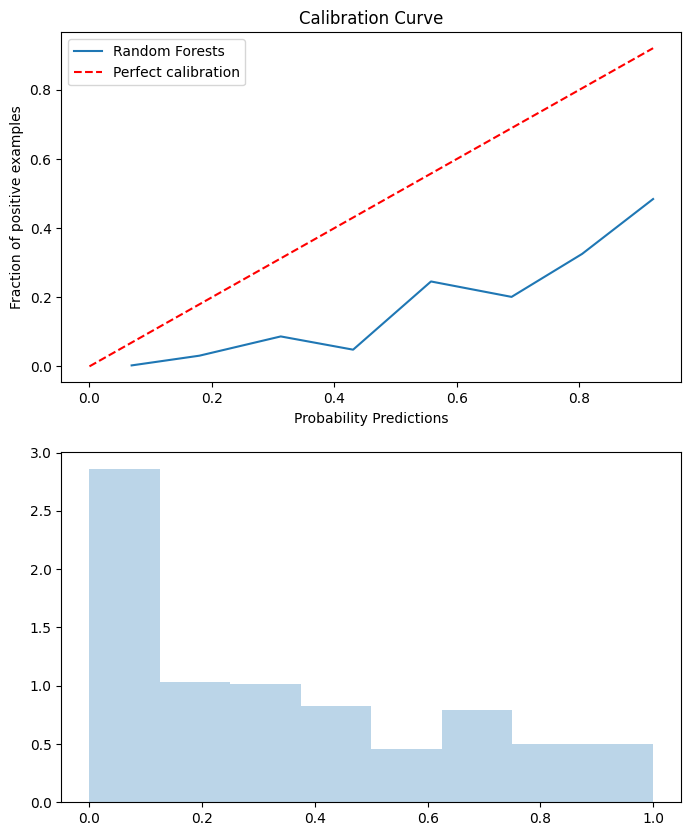

/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_r

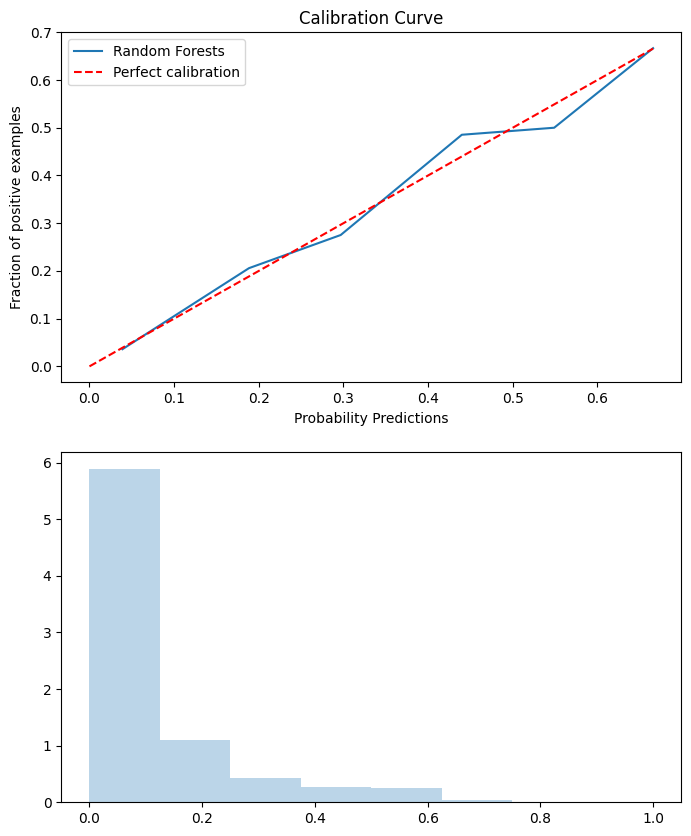

/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_r

Optimal threshold for F2 score: 0.5 F2 score at this threshold: 0.6015569709837226
Optimal threshold for MCC: 0.5 MCC at this threshold: 0.3972417588800244
Optimal threshold for weighted F2+MCC: 0.5 F2 score at this threshold: 0.6015569709837226 MCC at this threshold: 0.3972417588800244


/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/var/folders/85/jv4429f16015mpvgk9z0lmnh0000gp/T/ipykernel_20730/748089308.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  threshold_df = pd.concat([threshold_df, pd.DataFrame({


,Model,Threshold,F2 Score,MCC
0,Logistic Regression,0.01,0.372846,0.017238
1,Logistic Regression,0.02,0.372397,0.011107
2,Logistic Regression,0.03,0.376920,0.044064
3,Logistic Regression,0.04,0.386872,0.080568
4,Logistic Regression,0.05,0.400380,0.113615
...,...,...,...,...
95,Logistic Regression,0.96,0.011696,0.034598
96,Logistic Regression,0.97,0.005862,0.015287
97,Logistic Regression,0.98,0.000000,-0.007702
98,Logistic Regression,0.99,0.000000,0.000000


In [69]:
best_estimator_lr, best_params_lr, best_score_lr = grid_search(pipeline_lr, lr_parameters, X_train, y_train)
clean_params_lr = {k.replace('classifier__', ''): v for k, v in best_params_lr.items()}
tuned_pipeline_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        random_state=42,
        **clean_params_lr
    ))
])

calibrated_lr = calibrate_and_plot(tuned_pipeline_lr, X_train, y_train, X_test, y_test)
oof_probs_lr = generate_oof_predictions(tuned_pipeline_lr, X_train, y_train)
thresh_f2_lr, thresh_mcc_lr, thresh_weighted_lr, threshold_df_lr = optimize_thresholds("Logistic Regression", y_test, tuned_pipeline_lr.predict_proba(X_test)[:, 1])
print("Optimal threshold for F2 score:", thresh_f2_lr, "F2 score at this threshold:", threshold_df_lr[threshold_df_lr['Threshold'] == thresh_f2_lr]['F2 Score'].values[0])
print("Optimal threshold for MCC:", thresh_mcc_lr, "MCC at this threshold:", threshold_df_lr[threshold_df_lr['Threshold'] == thresh_mcc_lr]['MCC'].values[0])
print("Optimal threshold for weighted F2+MCC:", thresh_weighted_lr, "F2 score at this threshold:", threshold_df_lr[threshold_df_lr['Threshold'] == thresh_weighted_lr]['F2 Score'].values[0], "MCC at this threshold:", threshold_df_lr[threshold_df_lr['Threshold'] == thresh_weighted_lr]['MCC'].values[0])
threshold_df_lr

/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


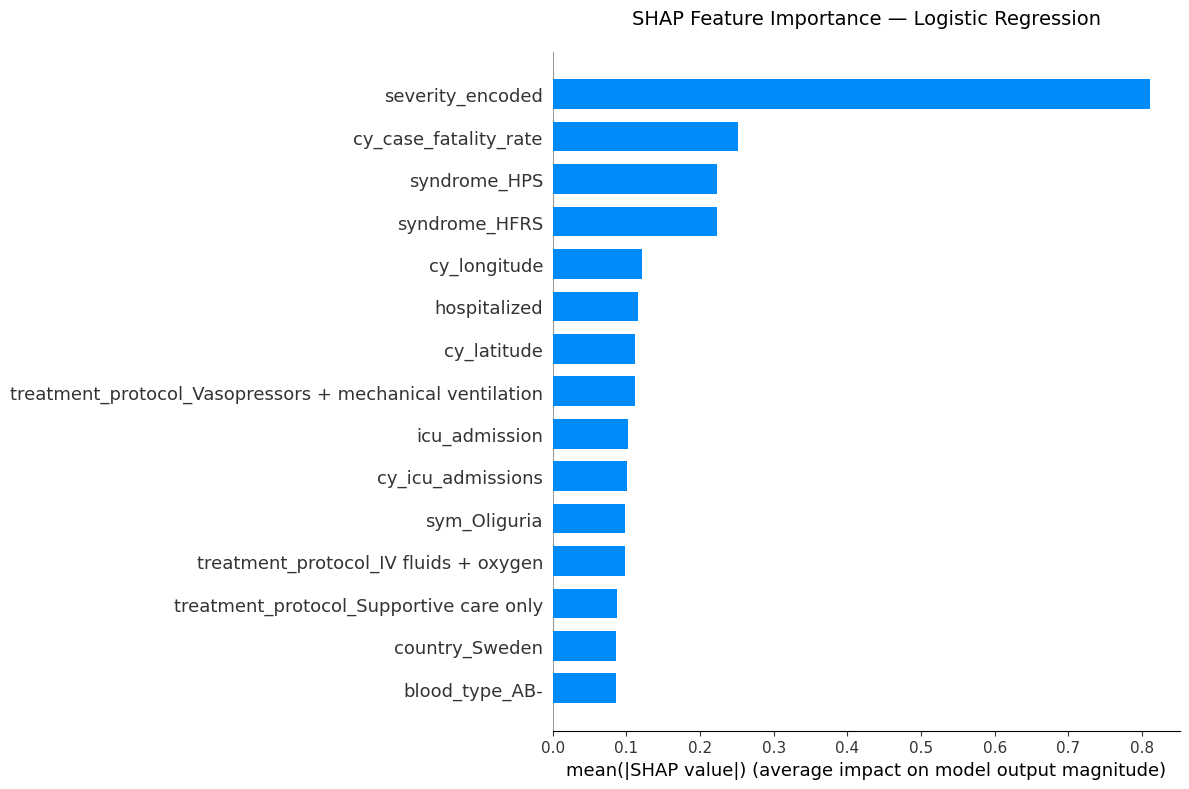

In [70]:
# Preprocess X_test through the pipeline steps manually
X_test_imputed = pd.DataFrame(
    tuned_pipeline_lr.named_steps['imputer'].transform(X_test),
    columns=X_test.columns
)
X_test_scaled = pd.DataFrame(
    tuned_pipeline_lr.named_steps['scaler'].transform(X_test_imputed),
    columns=X_test.columns
)

# Use LinearExplainer for logistic regression
explainer = shap.LinearExplainer(
    tuned_pipeline_lr.named_steps['classifier'],
    X_test_scaled
)
shap_values = explainer.shap_values(X_test_scaled)

# Summary plot
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_test.columns,
    plot_type='bar',
    max_display=15,
    plot_size=(12, 8),
    show=False
)
plt.title('SHAP Feature Importance — Logistic Regression', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

### Random Forest

In [71]:
rf_parameters = {
    'classifier__n_estimators': [50, 100, 200, 500],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__n_jobs': [-1]
}

In [72]:
best_estimator_rf, best_params_rf, best_score_rf = grid_search(pipeline_rf, rf_parameters, X_train, y_train)
clean_params_rf = {k.replace('classifier__', ''): v for k, v in best_params_rf.items()}
tuned_pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        **clean_params_rf
    ))
])

calibrated_rf = calibrate_and_plot(tuned_pipeline_rf, X_train, y_train, X_test, y_test)
oof_probs_rf = generate_oof_predictions(tuned_pipeline_rf, X_train, y_train)
thresh_f2_rf, thresh_mcc_rf, thresh_weighted_rf, threshold_df_rf = optimize_thresholds("Random Forest", y_test, tuned_pipeline_rf.predict_proba(X_test)[:, 1])
print("Optimal threshold for F2 score:", thresh_f2_rf, "F2 score at this threshold:", threshold_df_rf[threshold_df_rf['Threshold'] == thresh_f2_rf]['F2 Score'].values[0])
print("Optimal threshold for MCC:", thresh_mcc_rf, "MCC at this threshold:", threshold_df_rf[threshold_df_rf['Threshold'] == thresh_mcc_rf]['MCC'].values[0])
print("Optimal threshold for weighted F2+MCC:", thresh_weighted_rf, "F2 score at this threshold:", threshold_df_rf[threshold_df_rf['Threshold'] == thresh_weighted_rf]['F2 Score'].values[0], "MCC at this threshold:", threshold_df_rf[threshold_df_rf['Threshold'] == thresh_weighted_rf]['MCC'].values[0])
threshold_df_rf

Fitting 5 folds for each of 144 candidates, totalling 720 fits


KeyboardInterrupt: 

c:\Users\sweek\miniforge3\envs\sp26\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


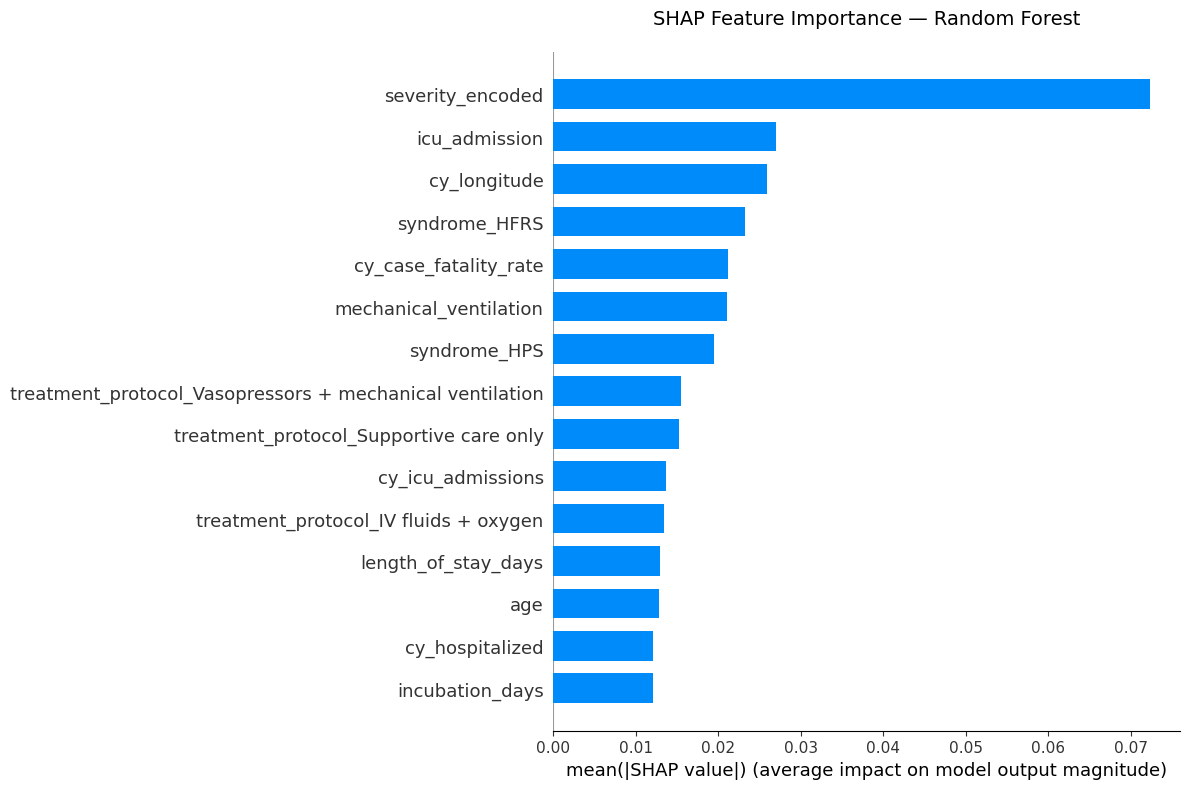

In [ ]:
X_test_imputed = pd.DataFrame(
    tuned_pipeline_rf.named_steps['imputer'].transform(X_test),
    columns=X_test.columns
)
X_test_scaled = pd.DataFrame(
    tuned_pipeline_rf.named_steps['scaler'].transform(X_test_imputed),
    columns=X_test.columns
)

explainer = shap.TreeExplainer(tuned_pipeline_rf.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_scaled)

# Older SHAP returns list [class0, class1]; newer returns 3-D ndarray (samples, features, classes)
if isinstance(shap_values, list):
    sv = shap_values[1]
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

shap.summary_plot(
    sv,
    X_test_scaled,
    feature_names=X_test.columns,
    plot_type='bar',
    max_display=15,
    plot_size=(12, 8),
    show=False
)
plt.title('SHAP Feature Importance — Random Forest', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

### XGBoost

In [ ]:
xgb_parameters = {
    'classifier__n_estimators': [50, 100, 200, 500],
    'classifier__max_depth': [3, 6, 10],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0],
}

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


c:\Users\sweek\miniforge3\envs\sp26\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\sweek\miniforge3\envs\sp26\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\sweek\miniforge3\envs\sp26\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\sweek\miniforge3\envs\sp26\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:41:57] WARNING: D:\bld\xgboost-split_1772124962567\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are n

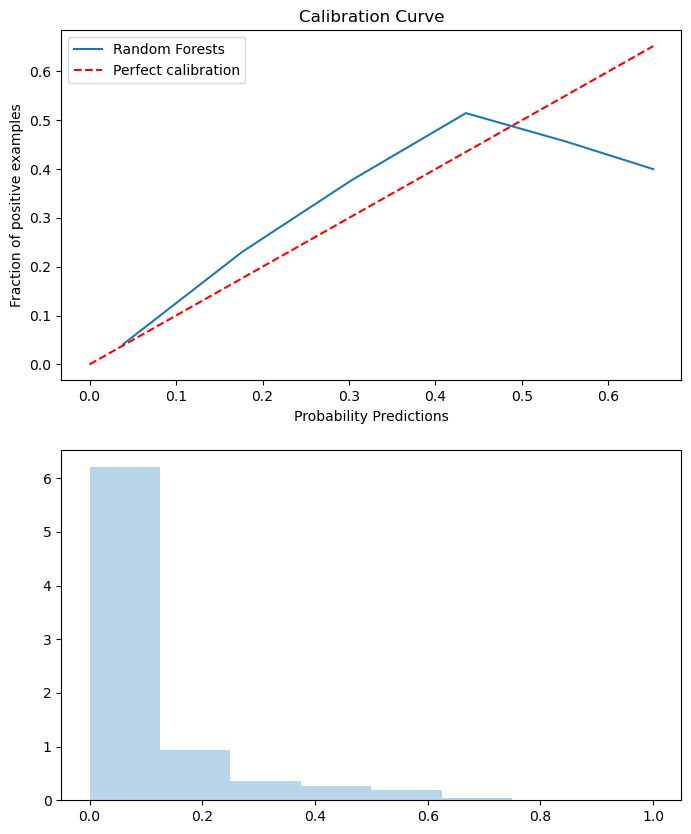

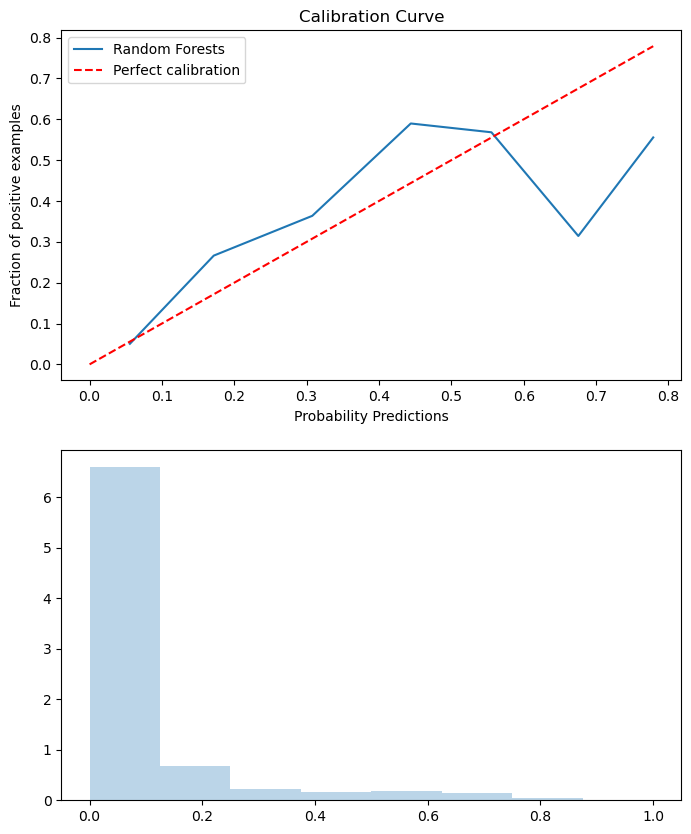

Optimal threshold for F2 score: 0.09 F2 score at this threshold: 0.5915492957746479
Optimal threshold for MCC: 0.14 MCC at this threshold: 0.40048426177549473
Optimal threshold for weighted F2+MCC: 0.11 F2 score at this threshold: 0.5849478390461997 MCC at this threshold: 0.3940791672522749


,Model,Threshold,F2 Score,MCC
0,XGBoost,0.01,0.372191,0.0
1,XGBoost,0.02,0.467706,0.219148
2,XGBoost,0.03,0.517068,0.278161
3,XGBoost,0.04,0.538585,0.302455
4,XGBoost,0.05,0.548571,0.314628
...,...,...,...,...
95,XGBoost,0.96,0.0,0.0
96,XGBoost,0.97,0.0,0.0
97,XGBoost,0.98,0.0,0.0
98,XGBoost,0.99,0.0,0.0


In [ ]:
best_estimator_xgb, best_params_xgb, best_score_xgb = grid_search(pipeline_xgb, xgb_parameters, X_train, y_train)
clean_params_xgb = {k.replace('classifier__', ''): v for k, v in best_params_xgb.items()}
tuned_pipeline_xgb = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(
        scale_pos_weight=1,
        random_state=42,
        **clean_params_xgb
    ))
])

calibrated_xgb = calibrate_and_plot(tuned_pipeline_xgb, X_train, y_train, X_test, y_test)
oof_probs_xgb = generate_oof_predictions(tuned_pipeline_xgb, X_train, y_train)
thresh_f2_xgb, thresh_mcc_xgb, thresh_weighted_xgb, threshold_df_xgb = optimize_thresholds("XGBoost", y_test, tuned_pipeline_xgb.predict_proba(X_test)[:, 1])
print("Optimal threshold for F2 score:", thresh_f2_xgb, "F2 score at this threshold:", threshold_df_xgb[threshold_df_xgb['Threshold'] == thresh_f2_xgb]['F2 Score'].values[0])
print("Optimal threshold for MCC:", thresh_mcc_xgb, "MCC at this threshold:", threshold_df_xgb[threshold_df_xgb['Threshold'] == thresh_mcc_xgb]['MCC'].values[0])
print("Optimal threshold for weighted F2+MCC:", thresh_weighted_xgb, "F2 score at this threshold:", threshold_df_xgb[threshold_df_xgb['Threshold'] == thresh_weighted_xgb]['F2 Score'].values[0], "MCC at this threshold:", threshold_df_xgb[threshold_df_xgb['Threshold'] == thresh_weighted_xgb]['MCC'].values[0])
threshold_df_xgb

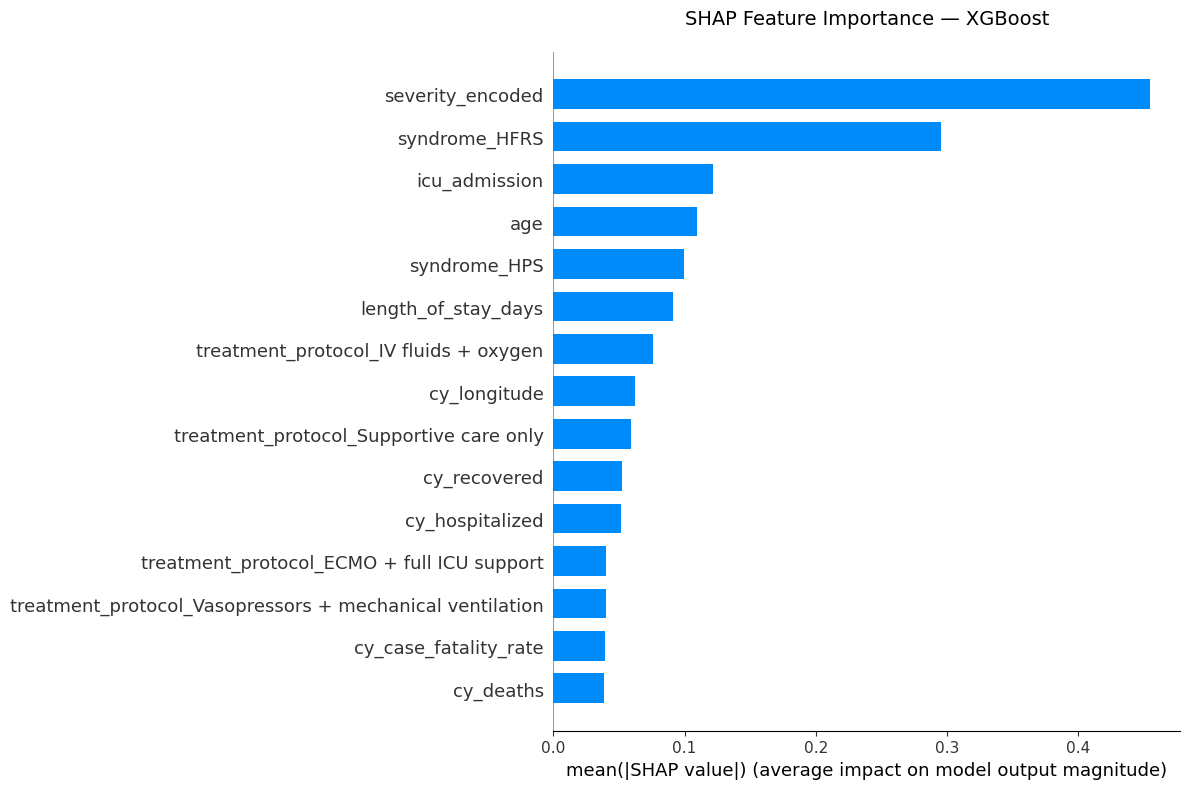

In [ ]:
X_test_imputed = pd.DataFrame(
    tuned_pipeline_xgb.named_steps['imputer'].transform(X_test),
    columns=X_test.columns
)

explainer = shap.TreeExplainer(tuned_pipeline_xgb.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_imputed)

shap.summary_plot(
    shap_values,
    X_test_imputed,
    feature_names=X_test.columns,
    plot_type='bar',
    max_display=15,
    plot_size=(12, 8),
    show=False
)
plt.title('SHAP Feature Importance — XGBoost', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

### LightGBM

In [74]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names"
)

In [75]:
lgbm_parameters = {
    'classifier__n_estimators': [50, 100, 200, 500],
    'classifier__max_depth': [3, 6, 10],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
}

Fitting 5 folds for each of 48 candidates, totalling 240 fits


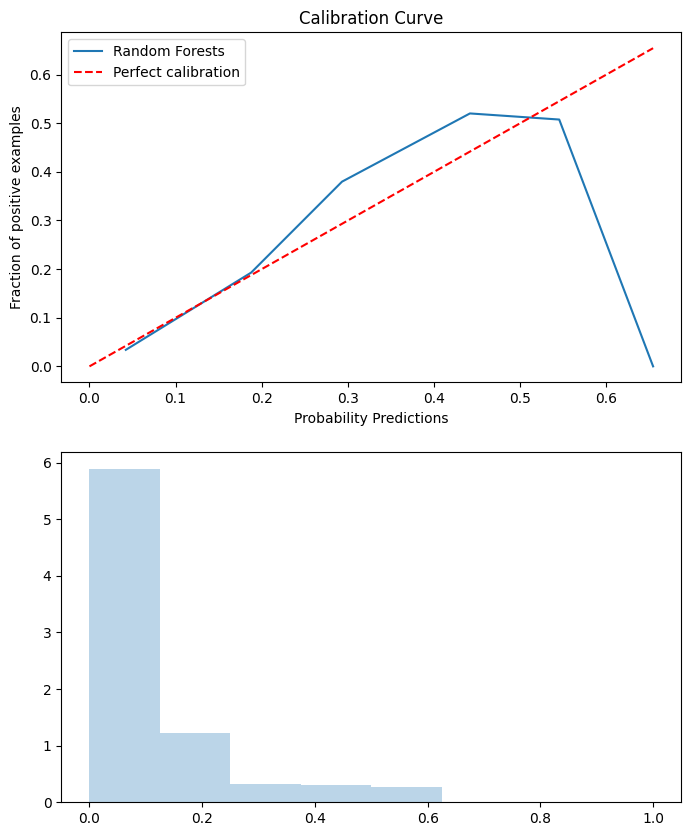

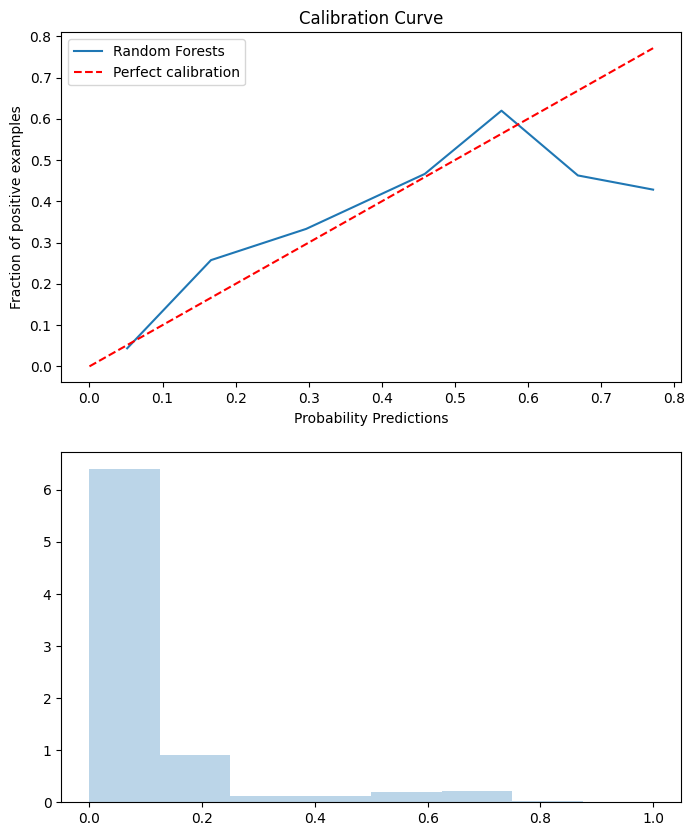

Optimal threshold for F2 score: 0.12 F2 score at this threshold: 0.5956678700361011
Optimal threshold for MCC: 0.2 MCC at this threshold: 0.4148264301936558
Optimal threshold for weighted F2+MCC: 0.12 F2 score at this threshold: 0.5956678700361011 MCC at this threshold: 0.39610133073923864


/var/folders/85/jv4429f16015mpvgk9z0lmnh0000gp/T/ipykernel_20730/748089308.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  threshold_df = pd.concat([threshold_df, pd.DataFrame({


,Model,Threshold,F2 Score,MCC
0,LightGBM,0.01,0.372191,0.000000
1,LightGBM,0.02,0.372191,0.000000
2,LightGBM,0.03,0.520159,0.282844
3,LightGBM,0.04,0.529683,0.293247
4,LightGBM,0.05,0.545992,0.311332
...,...,...,...,...
95,LightGBM,0.96,0.000000,0.000000
96,LightGBM,0.97,0.000000,0.000000
97,LightGBM,0.98,0.000000,0.000000
98,LightGBM,0.99,0.000000,0.000000


In [76]:
best_estimator_lgbm, best_params_lgbm, best_score_lgbm = grid_search(pipeline_lgbm, lgbm_parameters, X_train, y_train)
clean_params_lgbm = {k.replace('classifier__', ''): v for k, v in best_params_lgbm.items()}
tuned_pipeline_lgbm = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LGBMClassifier(
        scale_pos_weight=1,
        random_state=42,
        **clean_params_lgbm
    ))
])

calibrated_lgbm = calibrate_and_plot(tuned_pipeline_lgbm, X_train, y_train, X_test, y_test)
oof_probs_lgbm = generate_oof_predictions(tuned_pipeline_lgbm, X_train, y_train)
thresh_f2_lgbm, thresh_mcc_lgbm, thresh_weighted_lgbm, threshold_df_lgbm = optimize_thresholds("LightGBM", y_test, tuned_pipeline_lgbm.predict_proba(X_test)[:, 1])
print("Optimal threshold for F2 score:", thresh_f2_lgbm, "F2 score at this threshold:", threshold_df_lgbm[threshold_df_lgbm['Threshold'] == thresh_f2_lgbm]['F2 Score'].values[0])
print("Optimal threshold for MCC:", thresh_mcc_lgbm, "MCC at this threshold:", threshold_df_lgbm[threshold_df_lgbm['Threshold'] == thresh_mcc_lgbm]['MCC'].values[0])
print("Optimal threshold for weighted F2+MCC:", thresh_weighted_lgbm, "F2 score at this threshold:", threshold_df_lgbm[threshold_df_lgbm['Threshold'] == thresh_weighted_lgbm]['F2 Score'].values[0], "MCC at this threshold:", threshold_df_lgbm[threshold_df_lgbm['Threshold'] == thresh_weighted_lgbm]['MCC'].values[0])
threshold_df_lgbm

/Users/sadhanat/miniforge3/envs/hantavirus-ml/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


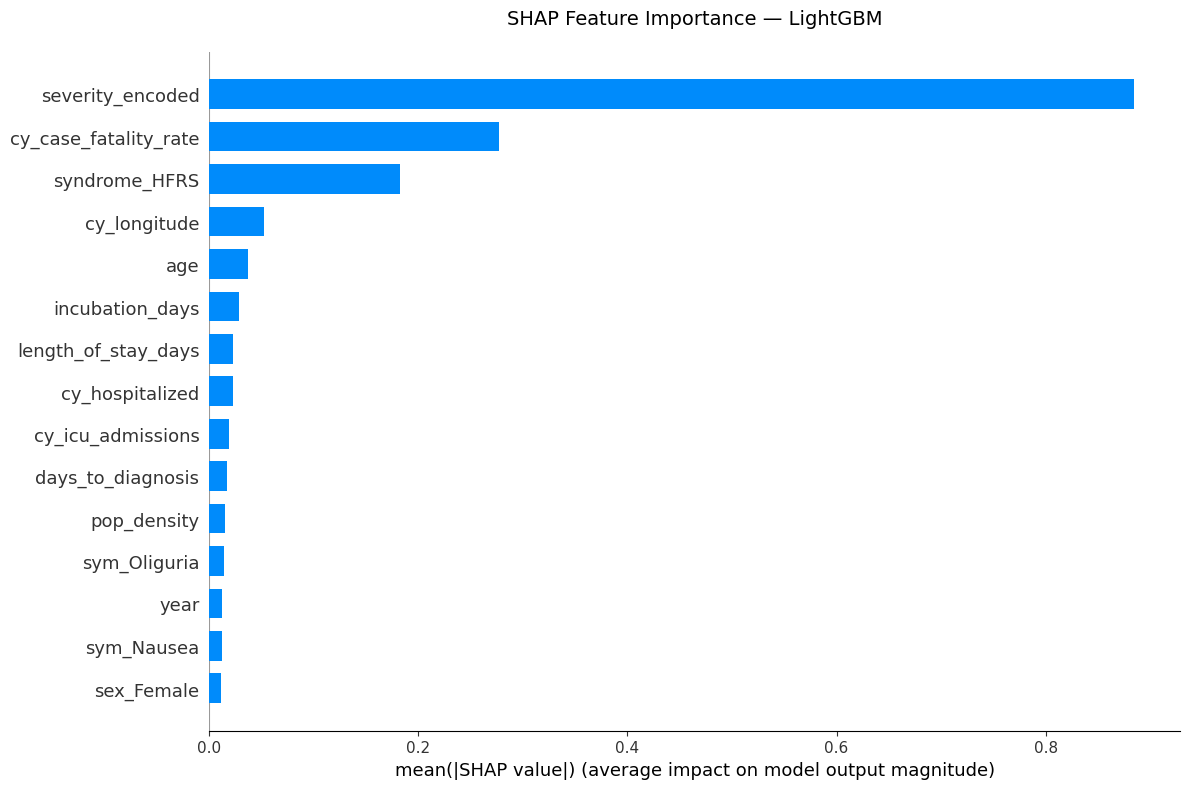

In [77]:
# Apply all preprocessing steps except the classifier
X_test_transformed = pd.DataFrame(
    tuned_pipeline_lgbm[:-1].transform(X_test),
    columns=X_test.columns
)

explainer = shap.TreeExplainer(tuned_pipeline_lgbm.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_transformed)

# Old SHAP → list; new SHAP → 3-D ndarray; LGBM binary → 2-D ndarray directly
if isinstance(shap_values, list):
    sv = shap_values[1]
elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

shap.summary_plot(
    sv,
    X_test_transformed,
    feature_names=X_test.columns,
    plot_type='bar',
    max_display=15,
    plot_size=(12, 8),
    show=False
)
plt.title('SHAP Feature Importance — LightGBM', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


# Statistical Analysis

## Statistical Bootstrap Analysis

In [78]:
def stratified_bootstrap_ci_f2(model, X_test, y_test, threshold, n_bootstraps=1000, alpha=0.95):
    # Define lists to hold bootstrap scores
    boot_f2_scores = []
    
    # Isolate class indices for stratification
    class_0_indices = np.where(y_test == 0)[0]
    class_1_indices = np.where(y_test == 1)[0]
    
    # Get predicted probabilities for the test set
    test_probs = model.predict_proba(X_test)[:, 1]
    
    for _ in range(n_bootstraps):
        # Stratified sampling: sample with replacement within each class
        boot_class_0 = np.random.choice(class_0_indices, size=len(class_0_indices), replace=True)
        boot_class_1 = np.random.choice(class_1_indices, size=len(class_1_indices), replace=True)
        boot_indices = np.concatenate([boot_class_0, boot_class_1])
        
        # Get the bootstrap sample
        y_boot = y_test.iloc[boot_indices]
        probs_bool = test_probs[boot_indices]
        y_boot_pred = (probs_bool >= threshold).astype(int)
        
        boot_f2_scores.append(fbeta_score(y_boot, y_boot_pred, beta=2, zero_division=0))
    
    # Find the confidence intervals
    f2_ci = np.percentile(boot_f2_scores, [(1 - alpha) / 2 * 100, (1 + alpha) / 2 * 100])
    
    return f2_ci

def stratified_bootstrap_ci_mcc(model, X_test, y_test, threshold, n_bootstraps=1000, alpha=0.95):
    # Define lists to hold bootstrap scores
    boot_mcc_scores = []
    
    # Isolate class indices for stratification
    class_0_indices = np.where(y_test == 0)[0]
    class_1_indices = np.where(y_test == 1)[0]
    
    # Get predicted probabilities for the test set
    test_probs = model.predict_proba(X_test)[:, 1]
    
    for _ in range(n_bootstraps):
        # Stratified sampling: sample with replacement within each class
        boot_class_0 = np.random.choice(class_0_indices, size=len(class_0_indices), replace=True)
        boot_class_1 = np.random.choice(class_1_indices, size=len(class_1_indices), replace=True)
        boot_indices = np.concatenate([boot_class_0, boot_class_1])
        
        # Get the bootstrap sample
        y_boot = y_test.iloc[boot_indices]
        probs_bool = test_probs[boot_indices]
        y_boot_pred = (probs_bool >= threshold).astype(int)
        
        boot_mcc_scores.append(matthews_corrcoef(y_boot, y_boot_pred))
        
    # Find the confidence intervals
    mcc_ci = np.percentile(boot_mcc_scores, [(1 - alpha) / 2 * 100, (1 + alpha) / 2 * 100])
    
    return mcc_ci

In [79]:
f2_cl_baseline_f2 = stratified_bootstrap_ci_f2(baseline_model, X_test_baseline, y_test_baseline, thresh_f2_lr)
f2_cl_baseline_mcc = stratified_bootstrap_ci_mcc(baseline_model, X_test_baseline, y_test_baseline, thresh_f2_lr)
print(f"Baseline Model - F2 Score 95% CI: {f2_cl_baseline_f2}, MCC 95% CI: {f2_cl_baseline_mcc}")
f2_cl_lr_f2 = stratified_bootstrap_ci_f2(calibrated_lr, X_test, y_test, thresh_f2_lr)
f2_cl_lr_mcc = stratified_bootstrap_ci_mcc(calibrated_lr, X_test, y_test, thresh_f2_lr)
print(f"Logistic Regression - F2 Score 95% CI: {f2_cl_lr_f2}, MCC 95% CI: {f2_cl_lr_mcc}")
f2_cl_rf_f2 = stratified_bootstrap_ci_f2(calibrated_rf, X_test, y_test, thresh_f2_rf)
f2_cl_rf_mcc = stratified_bootstrap_ci_mcc(calibrated_rf, X_test, y_test, thresh_f2_rf)
print(f"Random Forest - F2 Score 95% CI: {f2_cl_rf_f2}, MCC 95% CI: {f2_cl_rf_mcc}")
f2_cl_xgb_f2 = stratified_bootstrap_ci_f2(calibrated_xgb, X_test, y_test, thresh_f2_xgb)
f2_cl_xgb_mcc = stratified_bootstrap_ci_mcc(calibrated_xgb, X_test, y_test, thresh_f2_xgb)
print(f"XGBoost - F2 Score 95% CI: {f2_cl_xgb_f2}, MCC 95% CI: {f2_cl_xgb_mcc}")
f2_cl_lgbm_f2 = stratified_bootstrap_ci_f2(calibrated_lgbm, X_test, y_test, thresh_f2_lgbm)
f2_cl_lgbm_mcc = stratified_bootstrap_ci_mcc(calibrated_lgbm, X_test, y_test, thresh_f2_lgbm)
print(f"LightGBM - F2 Score 95% CI: {f2_cl_lgbm_f2}, MCC 95% CI: {f2_cl_lgbm_mcc}")

Baseline Model - F2 Score 95% CI: [0.15350457 0.2665995 ], MCC 95% CI: [0.19650395 0.33991638]
Logistic Regression - F2 Score 95% CI: [0.15350457 0.27100998], MCC 95% CI: [0.19922545 0.34649275]


NameError: name 'calibrated_rf' is not defined

## McNemar Test and Cochran's Q Test

In [ ]:
y_pred_baseline = (baseline_model.predict_proba(X_test_baseline)[:, 1] >= 0.5).astype(int)

y_pred_lr = (calibrated_lr.predict_proba(X_test)[:, 1] >= thresh_weighted_lr).astype(int)
y_pred_rf = (calibrated_rf.predict_proba(X_test)[:, 1] >= thresh_weighted_rf).astype(int)
y_pred_xgb = (calibrated_xgb.predict_proba(X_test)[:, 1] >= thresh_weighted_xgb).astype(int)
y_pred_lgbm = (calibrated_lgbm.predict_proba(X_test)[:, 1] >= thresh_weighted_lgbm).astype(int)

# McNemar's test
def mcnemar_test(y_true, y_pred_a, y_pred_b):
    y_true_np = np.array(y_true).astype(int)
    y_pred_a_np = np.array(y_pred_a).astype(int)
    y_pred_b_np = np.array(y_pred_b).astype(int)
    
    table = mcnemar_table(y_true_np, y_pred_a_np, y_pred_b_np)
    
    # Check all off-diagonal elements
    discordant = table[0,1] + table[1,0]
    print(f"Discordant pairs: {discordant}")
    
    if discordant == 0:
        return None, None
    
    result = sm_mcnemar(table, exact=True, correction=True)
    return result.statistic, result.pvalue

# Cochran's Q test for multiple models
def cochrans_q_test(y_true, *y_preds):
    y_true_np = np.array(y_true).astype(int)
    y_preds_np = [np.array(y).astype(int) for y in y_preds]
    q, p = cochrans_q(y_true_np, *y_preds_np)
    return q, p

# Compare baseline to each model using McNemar's test
models = {
    'Logistic Regression': y_pred_lr_f2,
    'Random Forest': y_pred_rf_f2,
    'XGBoost': y_pred_xgb_f2,
    'LightGBM': y_pred_lgbm_f2
}
for model_name, y_pred in models.items():
    chi2, p = mcnemar_test(y_test, y_pred_baseline, y_pred)
    if chi2 is not None:
        print(f"McNemar's test comparing Baseline to {model_name} (F2 threshold): chi2={chi2:.4f}, p={p}")
    else:
        print(f"McNemar's test comparing Baseline is not valid for {model_name} (F2 threshold) due to no discordant pairs.")

# Cochran's Q test comparing all models at once (F2 threshold)
q, p = cochrans_q_test(y_test, y_pred_baseline, y_pred_lr, y_pred_rf, y_pred_xgb, y_pred_lgbm)
print(f"Cochran's Q test comparing all models (F2 threshold): Q={q:.4f}, p={p}")

Discordant pairs: 62
McNemar's test comparing Baseline to Logistic Regression (F2 threshold): chi2=25.0000, p=0.16188140552559763
Discordant pairs: 202
McNemar's test comparing Baseline to Random Forest (F2 threshold): chi2=73.0000, p=9.912782420372888e-05
Discordant pairs: 385
McNemar's test comparing Baseline to XGBoost (F2 threshold): chi2=104.0000, p=6.415763094366532e-20
Discordant pairs: 324
McNemar's test comparing Baseline to LightGBM (F2 threshold): chi2=99.0000, p=2.0112706732272523e-12
Cochran's Q test comparing all models (F2 threshold): Q=158.7856, p=2.6629730396991922e-33


In [ ]:
# Check types and shapes
print(type(y_test), type(y_pred_baseline), type(y_pred_lr_f2))
print(y_test.shape, y_pred_baseline.shape, y_pred_lr_f2.shape)

# Check if predictions are actually different
print("Baseline vs LR disagreements:", (y_pred_baseline != y_pred_lr_f2).sum())
print("Baseline vs RF disagreements:", (y_pred_baseline != y_pred_rf_f2).sum())

# Check the actual contingency table
table = mcnemar_table(y_test.values, y_pred_baseline, y_pred_lr_f2)
print("Contingency table:")
print(table)

<class 'pandas.Series'> <class 'numpy.ndarray'> <class 'numpy.ndarray'>
(2000,) (2000,) (2000,)
Baseline vs LR disagreements: 62
Baseline vs RF disagreements: 202
Contingency table:
[[1764   25]
 [  37  174]]


In [ ]:
# saves the best model to applied to the locally hostable demo

bundle = {
    "pipeline":     calibrated_lgbm,
    "feature_cols": X_train.columns.tolist(),
    "threshold":    float(thresh_f2_lgbm),
    "model_name":   "LightGBM",
}
joblib.dump(bundle, "model.pkl", compress=3)
print("Saved model.pkl")

Saved model.pkl ✅
